In [1]:
import os
os.environ["VS30_MODEL_BASE_DATA_DIR"] = "/Users/claudy/dev/work/data/vs30"

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go

from IPython.display import HTML, display

import ml_vs30_model as vs30

In [2]:
usgs_df = pd.read_csv("/Users/claudy/dev/work/data/vs30/maurer_original/USGS VS30 compilation 2020.csv", index_col=0).rename(columns={
    "LATITUDE": "lat",
    "LONGITUDE": "lon",
    "DATUM": "datum",
    "NETWORK_ST": "network",
    "STATION_NA": "station_name",
    "METHOD": "method",
    "VS30__M_S_": "vs30",
    "MAX_DEPTH": "max_depth",
}).drop(columns=["CONTACT", "REFERENCE", "URL", "GEOLOGIC_D", "COMMENTS"])

In [3]:
us_df = pd.read_parquet("/Users/claudy/dev/work/data/vs30/datasets/geyin_maurer_dataset.parquet")

## Spatial Distribution

In [4]:
fig = go.Figure()

fig.update_layout(width=1400, height=800,
                  margin=dict(l=10, r=10, t=30, b=10),
                  map=dict(zoom=3, center=dict(lat=us_df.lat.mean(), lon=us_df.lon.mean())),
                  showlegend=False
)

# # USGS
# fig.add_trace(go.Scattermap(
#     lon = usgs_df['lon'],
#     lat = usgs_df['lat'],
#     name='USGS VS30 Compilation',
#     mode = 'markers',
#     marker = dict(
#         size = 4,
#         color="red")
# ))

hover_template = (
    "lat: %{lat}<br>"
    "lon: %{lon}<br>"
    "vs30: %{customdata[0]} m/s<br>"
    "Depth to Bedrock: %{customdata[1]} m<br>"
    "Compound Topographic Index: %{customdata[2]}<br>"
    "Geomorphologic Phonotype: %{customdata[3]}<br>"
    "Topographic Slope: %{customdata[4]}<br>"
    "Topographic Position Index: %{customdata[5]}<br>"
    "Profile Curvature: %{customdata[6]}<br>"
    "Tangential Curvature: %{customdata[7]}<br>"
    "Roughness: %{customdata[8]}<br>"
    "Terrain Ruggedness Index: %{customdata[9]}<br>"
    "Vector Ruggedness Measure: %{customdata[10]}<br>"
    "Landform Entropy: %{customdata[11]}<br>"
    "Landform Uniformity: %{customdata[12]}<br>"
    "Landform Shannon Index: %{customdata[13]}<br>"
    "<extra></extra>"
)
hover_columns = [
    "vs30",
    vs30.constants.InputVariable.AbsoluteDepthToBedrock,
    vs30.constants.InputVariable.CompoundTopgraphicIndex,
    vs30.constants.InputVariable.Geomorphon,
    vs30.constants.InputVariable.TopographicSlope,
    vs30.constants.InputVariable.TopographicPositionIndex,
    vs30.constants.InputVariable.ProfileCurvature,
    vs30.constants.InputVariable.TangentialCurvature,
    vs30.constants.InputVariable.Roughness,
    vs30.constants.InputVariable.TerrainRuggednessIndex,
    vs30.constants.InputVariable.VectorRuggednessMeasure,
    vs30.constants.InputVariable.LandformEntropy,
    vs30.constants.InputVariable.LandformUniformity,
    vs30.constants.InputVariable.LandformShannonIndex,
]

# US
fig.add_trace(go.Scattermap(
    lon = us_df['lon'],
    lat = us_df['lat'],
    name='US Measurements',
    mode = 'markers',
    marker = dict(
        size = 4,
        color="blue"),
    hovertemplate=hover_template,
    customdata=us_df[hover_columns].values
))


# Negative Depth to Bedrock
# m = us_df[vs30.constants.InputVariable.AbsoluteDepthToBedrock] < 0

# Negative -9999 for Geomorph90 dataset
m = us_df[vs30.constants.InputVariable.CompoundTopgraphicIndex] < -1000

fig.add_trace(go.Scattermap(
    lon = us_df.loc[m, 'lon'],
    lat = us_df.loc[m, 'lat'],
    mode = 'markers',
    marker = dict(
        size = 4,
        color="red"),
    hovertemplate=hover_template,
    customdata=us_df.loc[m, hover_columns].values
))



## VS30 Distribution

In [5]:
display(HTML(us_df["vs30"].to_frame().describe().to_html()))

,vs30
count,6989.000000
mean,384.168093
std,309.537913
min,0.000000
25%,214.000000
50%,284.000000
75%,433.000000
max,7020.275749


**There are clearly some outliers at the extremes, this will need to addressed prior to model training!**

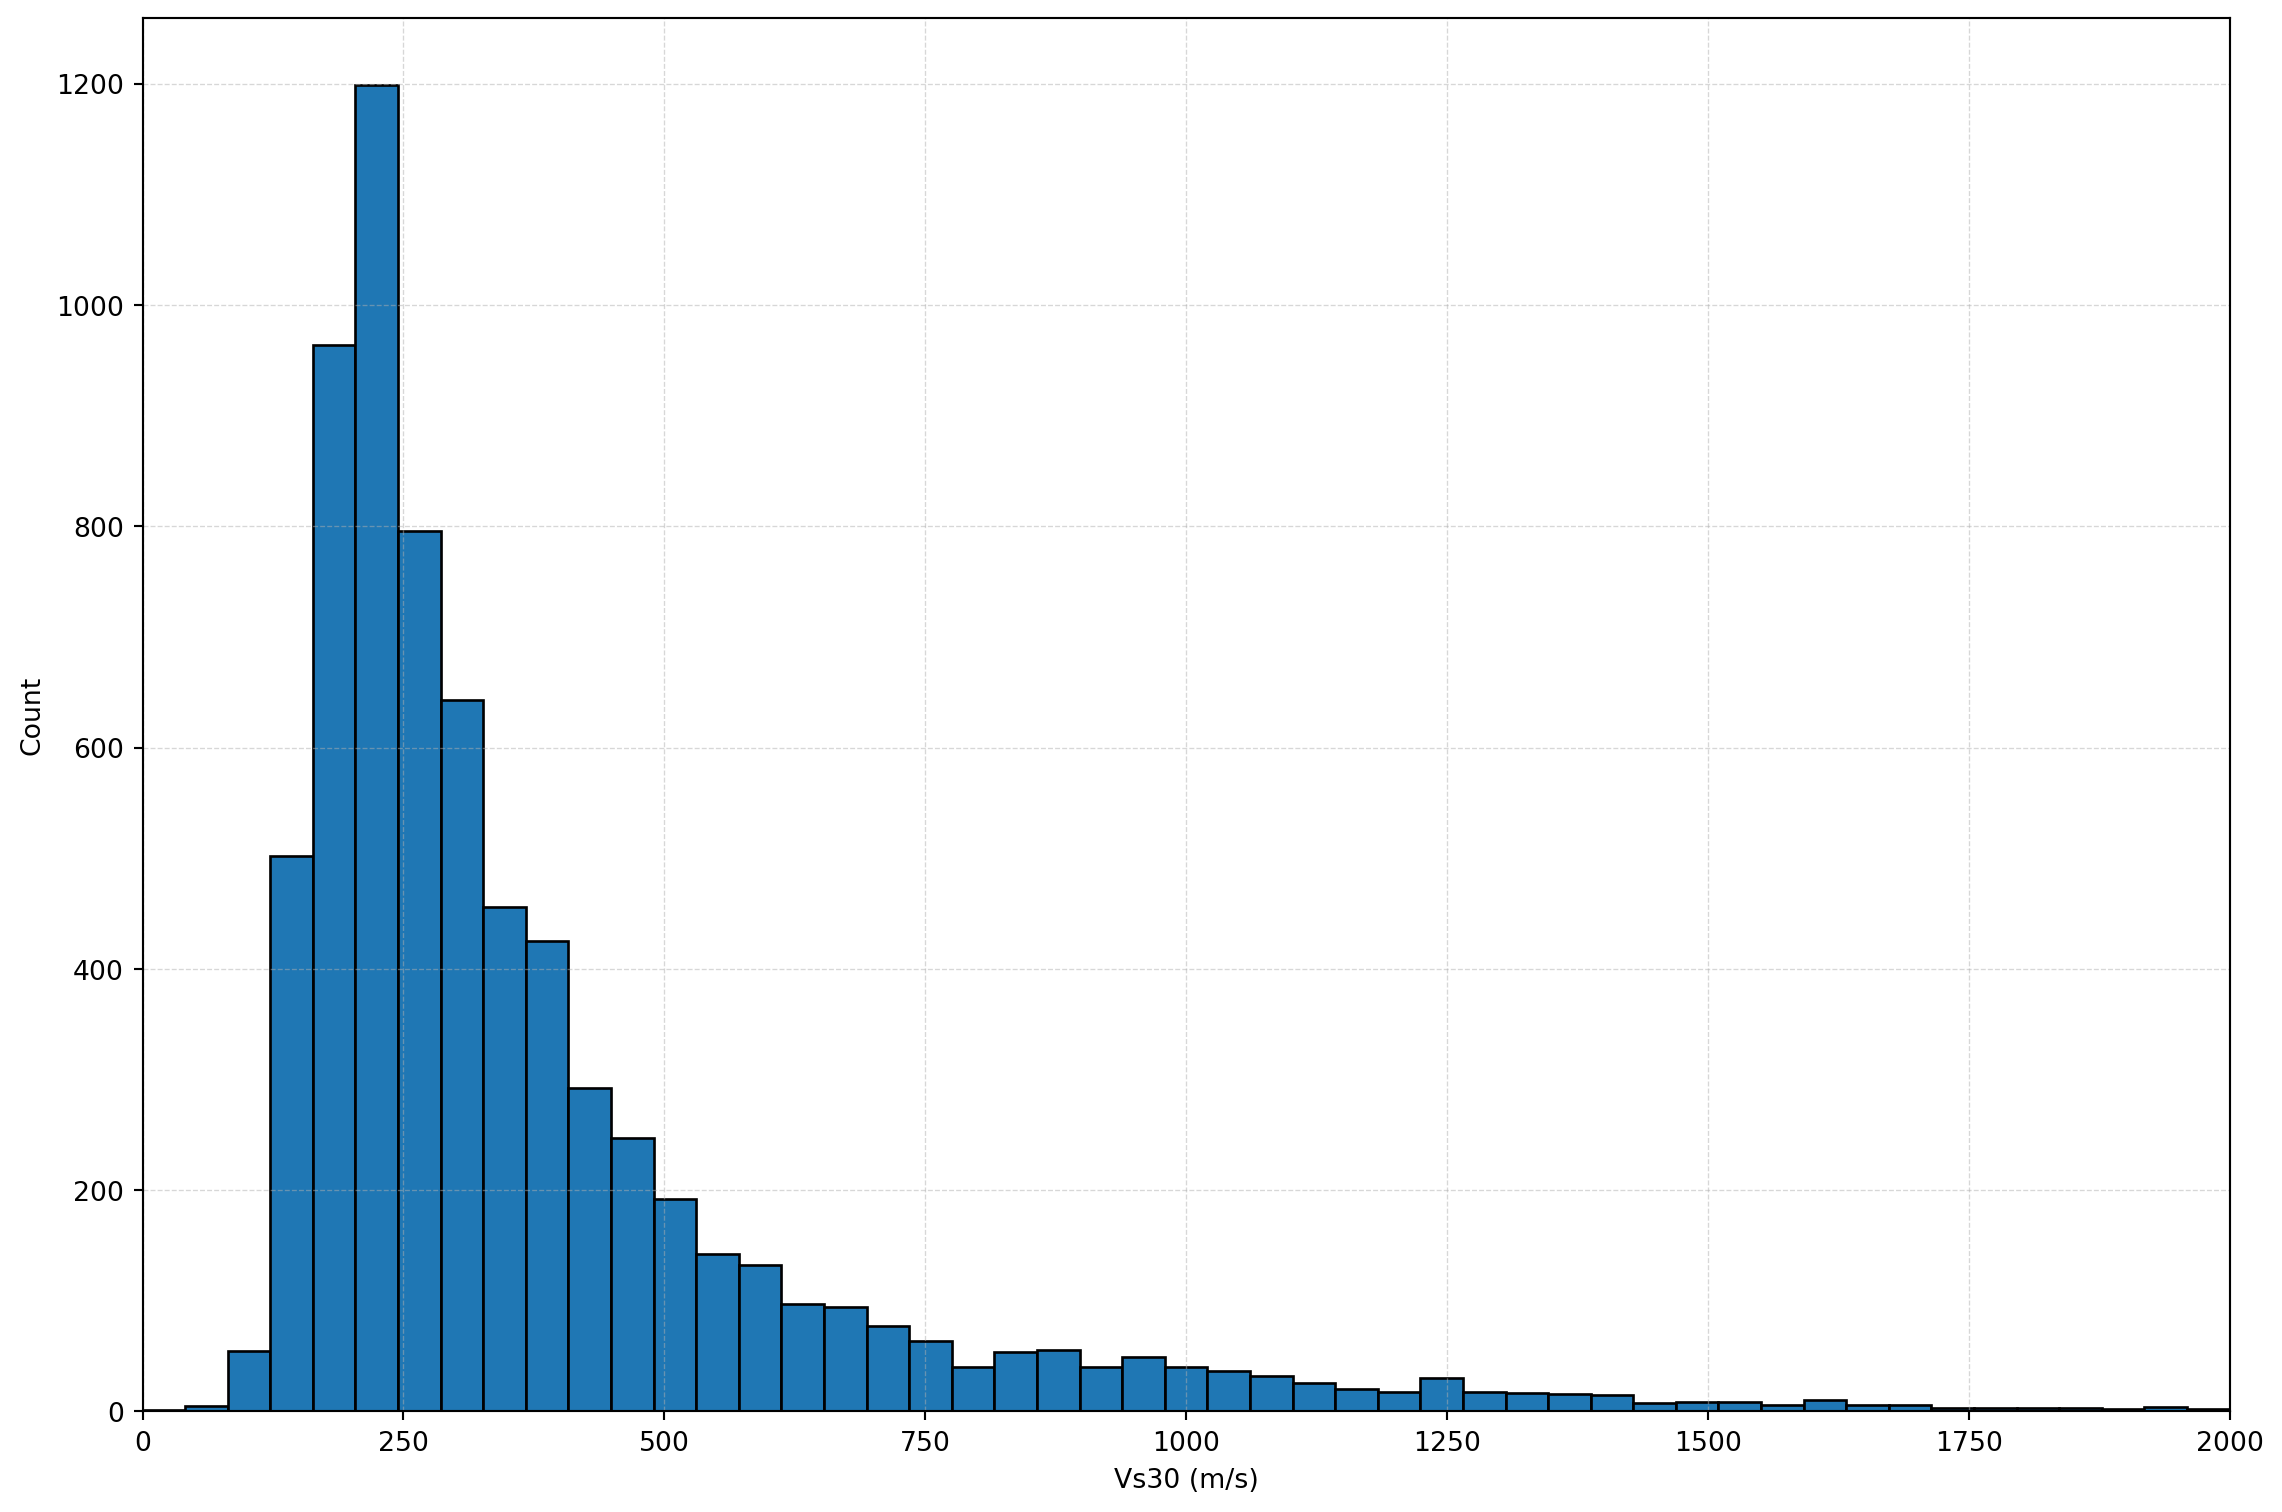

In [6]:
bins = np.linspace(0, 2000, 50)

fig, ax = plt.subplots(figsize=(12, 8))

ax.hist(us_df['vs30'], bins=bins, edgecolor='black')

ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax.set_xlabel("Vs30 (m/s)")
ax.set_ylabel("Count")
ax.set_xlim(bins.min(), bins.max())

fig.tight_layout()

## Input Variables

### Depth to Bedrock
TODO: Why are there negative depth to bedrock values???
Unsure, why these are negative, however will just use the average of nearby points.

In [7]:
us_df.loc[us_df[vs30.constants.InputVariable.AbsoluteDepthToBedrock] < 0]

,lon,lat,vs30,roughness,topographic_slope,compound_topographic_index,geomorphon,profile_curvature,tangential_curvature,terrain_ruggedness_index,topographic_position_index,vector_ruggedness_measure,landform_shannon_index,landform_entropy,landform_uniformity,absolute_depth_to_bedrock,depth_to_groundwater
4156,-88.68481,37.12645,399.287218,2.258416,0.281701,-0.544966,1,-0.000077,-0.000076,1.126973,-0.571232,0.000026,0.233792,0.440595,0.786169,-99999,-2.503442
4267,-85.68700,38.28700,317.544047,2.954793,0.631694,-0.076492,1,0.000041,-0.000013,0.852758,0.105154,0.000019,0.376770,0.574880,0.709780,-99999,-5.205162


In [8]:
us_df[vs30.constants.InputVariable.AbsoluteDepthToBedrock].describe()

count     6989.000000
mean      2656.932751
std       3020.163270
min     -99999.000000
25%       1083.000000
50%       1979.000000
75%       3327.000000
max      31917.000000
Name: absolute_depth_to_bedrock, dtype: float64

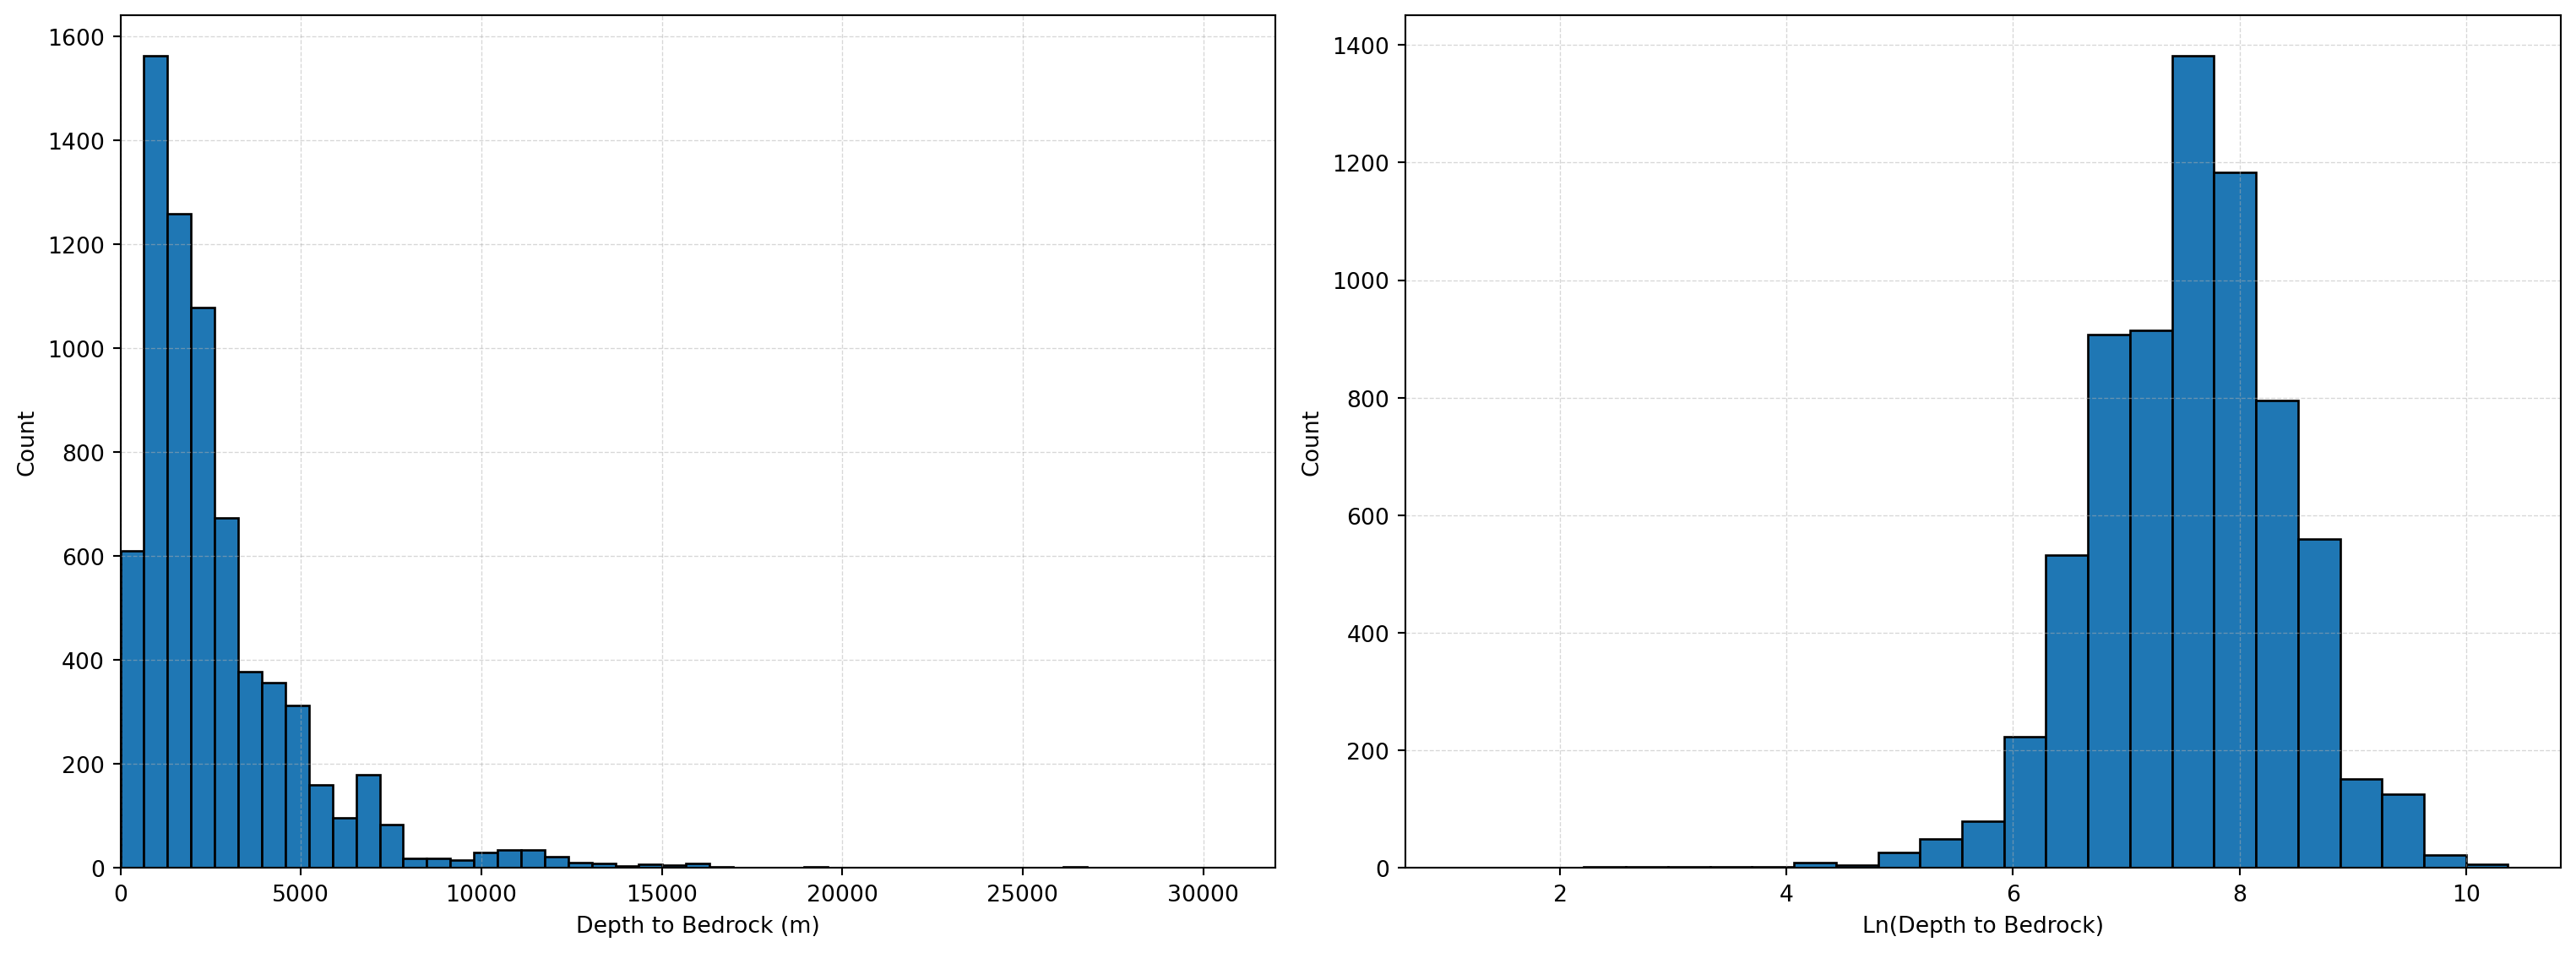

In [9]:
bins = np.linspace(0, 32_000, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df[vs30.constants.InputVariable.AbsoluteDepthToBedrock], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Depth to Bedrock (m)")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

ax2.hist(np.log(us_df.loc[us_df[vs30.constants.InputVariable.AbsoluteDepthToBedrock] > 0,vs30.constants.InputVariable.AbsoluteDepthToBedrock].values), bins=25, edgecolor='black')
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Ln(Depth to Bedrock)")
ax2.set_ylabel("Count")


fig.tight_layout()

Log transform seems to be a nice option for absolute depth to bedrock

### Depth to Groundwater

In [10]:
us_df[vs30.constants.InputVariable.DepthToGroundwater].describe()

count    6.989000e+03
mean    -1.141953e+01
std      2.120829e+01
min     -2.401165e+02
25%     -9.784285e+00
50%     -2.845665e+00
75%     -9.218857e-01
max     -5.684342e-14
Name: depth_to_groundwater, dtype: float64

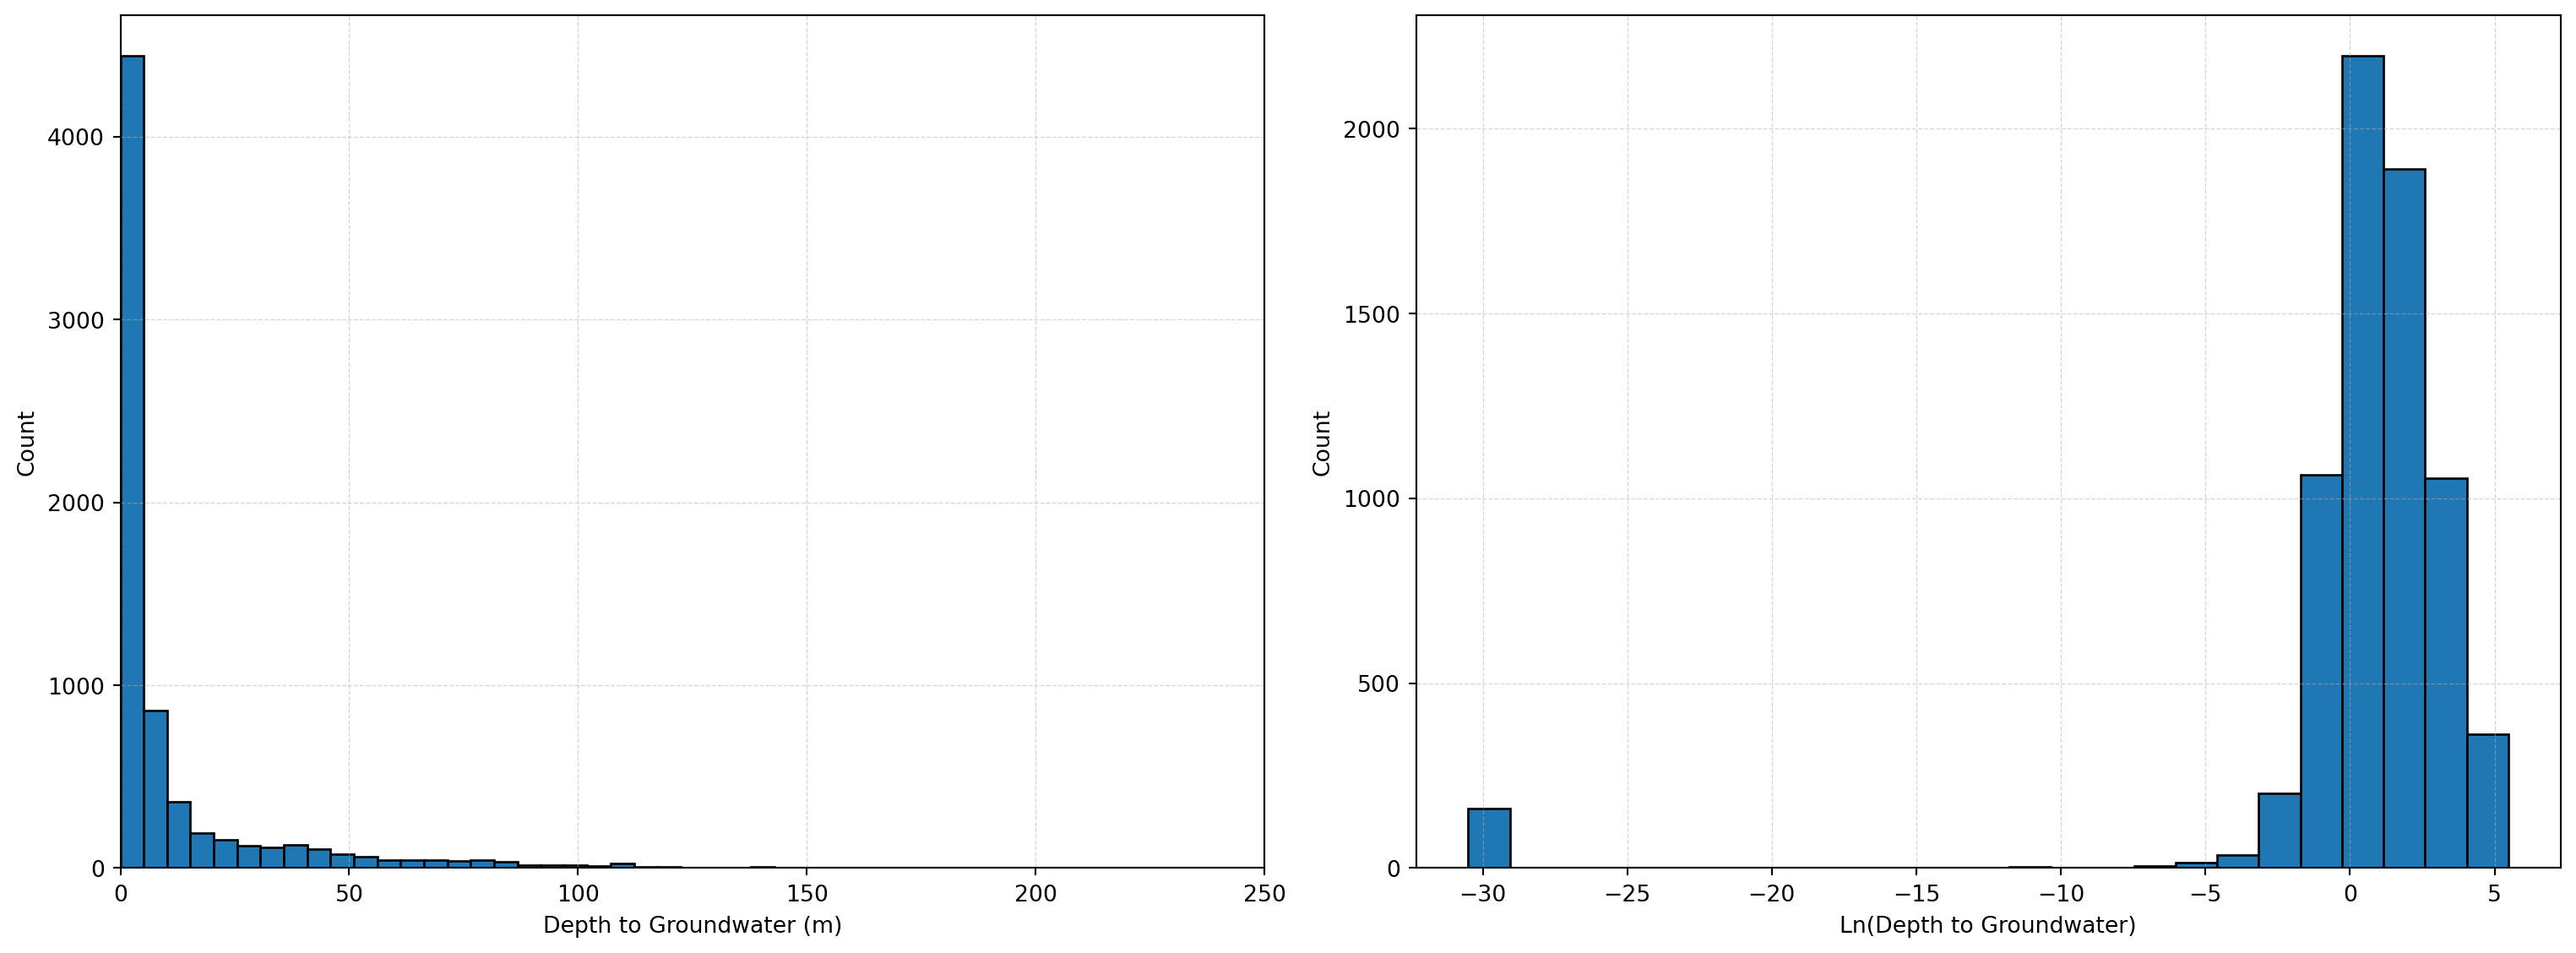

In [11]:
bins = np.linspace(0, 250, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df[vs30.constants.InputVariable.DepthToGroundwater] * -1, bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Depth to Groundwater (m)")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

ax2.hist(np.log(us_df[vs30.constants.InputVariable.DepthToGroundwater].values * -1), bins=25, edgecolor='black')
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Ln(Depth to Groundwater)")
ax2.set_ylabel("Count")


fig.tight_layout()

Again log-transform seems like a reasonable option. However, there are a few outliers (extremley shallow). Could just use min/max scaling with fixed limits, e.g. -5, 5. Maybe followed by z-normalization?

### Compound Topographic Index

In [12]:
us_df[vs30.constants.InputVariable.CompoundTopgraphicIndex].describe()

count    6989.000000
mean      -12.124790
std       358.644226
min     -9999.000000
25%        -0.660757
50%         0.092297
75%         1.495041
max        17.832039
Name: compound_topographic_index, dtype: float64

In [13]:
m = us_df[vs30.constants.InputVariable.CompoundTopgraphicIndex] < -1000
us_df.loc[m]

,lon,lat,vs30,roughness,topographic_slope,compound_topographic_index,geomorphon,profile_curvature,tangential_curvature,terrain_ruggedness_index,topographic_position_index,vector_ruggedness_measure,landform_shannon_index,landform_entropy,landform_uniformity,absolute_depth_to_bedrock,depth_to_groundwater
1686,-122.271840,37.763150,198.000000,-9999.0,-9999.0,-9999.0,0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-0.000000,-0.000000,1.000000,1474,-5.684342e-14
2181,-124.017882,44.914005,274.000000,-9999.0,-9999.0,-9999.0,0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-0.000000,-0.000000,1.000000,2994,-5.684342e-14
2396,-123.105991,49.038135,238.300000,-9999.0,-9999.0,-9999.0,0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-0.000000,-0.000000,1.000000,2677,-5.599370e-01
2398,-123.112854,49.047844,294.200000,-9999.0,-9999.0,-9999.0,0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-0.000000,-0.000000,1.000000,3109,-2.799649e-01
2399,-123.119015,49.048917,219.700000,-9999.0,-9999.0,-9999.0,0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,0.601924,0.902684,0.565297,2780,-9.144688e-02
2401,-123.137852,49.056093,201.000000,-9999.0,-9999.0,-9999.0,0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-0.000000,-0.000000,1.000000,2898,-5.684342e-14
2402,-123.141964,49.058337,201.000000,-9999.0,-9999.0,-9999.0,0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-0.000000,-0.000000,1.000000,3158,-5.684342e-14
3963,-124.017882,44.914005,420.081135,-9999.0,-9999.0,-9999.0,0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-0.000000,-0.000000,1.000000,2994,-5.684342e-14
6404,-90.100000,30.000000,154.000000,-9999.0,-9999.0,-9999.0,0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-0.000000,-0.000000,1.000000,2550,-1.515520e-01


In [14]:
us_df.loc[~m, vs30.constants.InputVariable.CompoundTopgraphicIndex].describe()

count    6980.000000
mean        0.752271
std         2.385925
min        -4.176440
25%        -0.659102
50%         0.094347
75%         1.495386
max        17.832039
Name: compound_topographic_index, dtype: float64

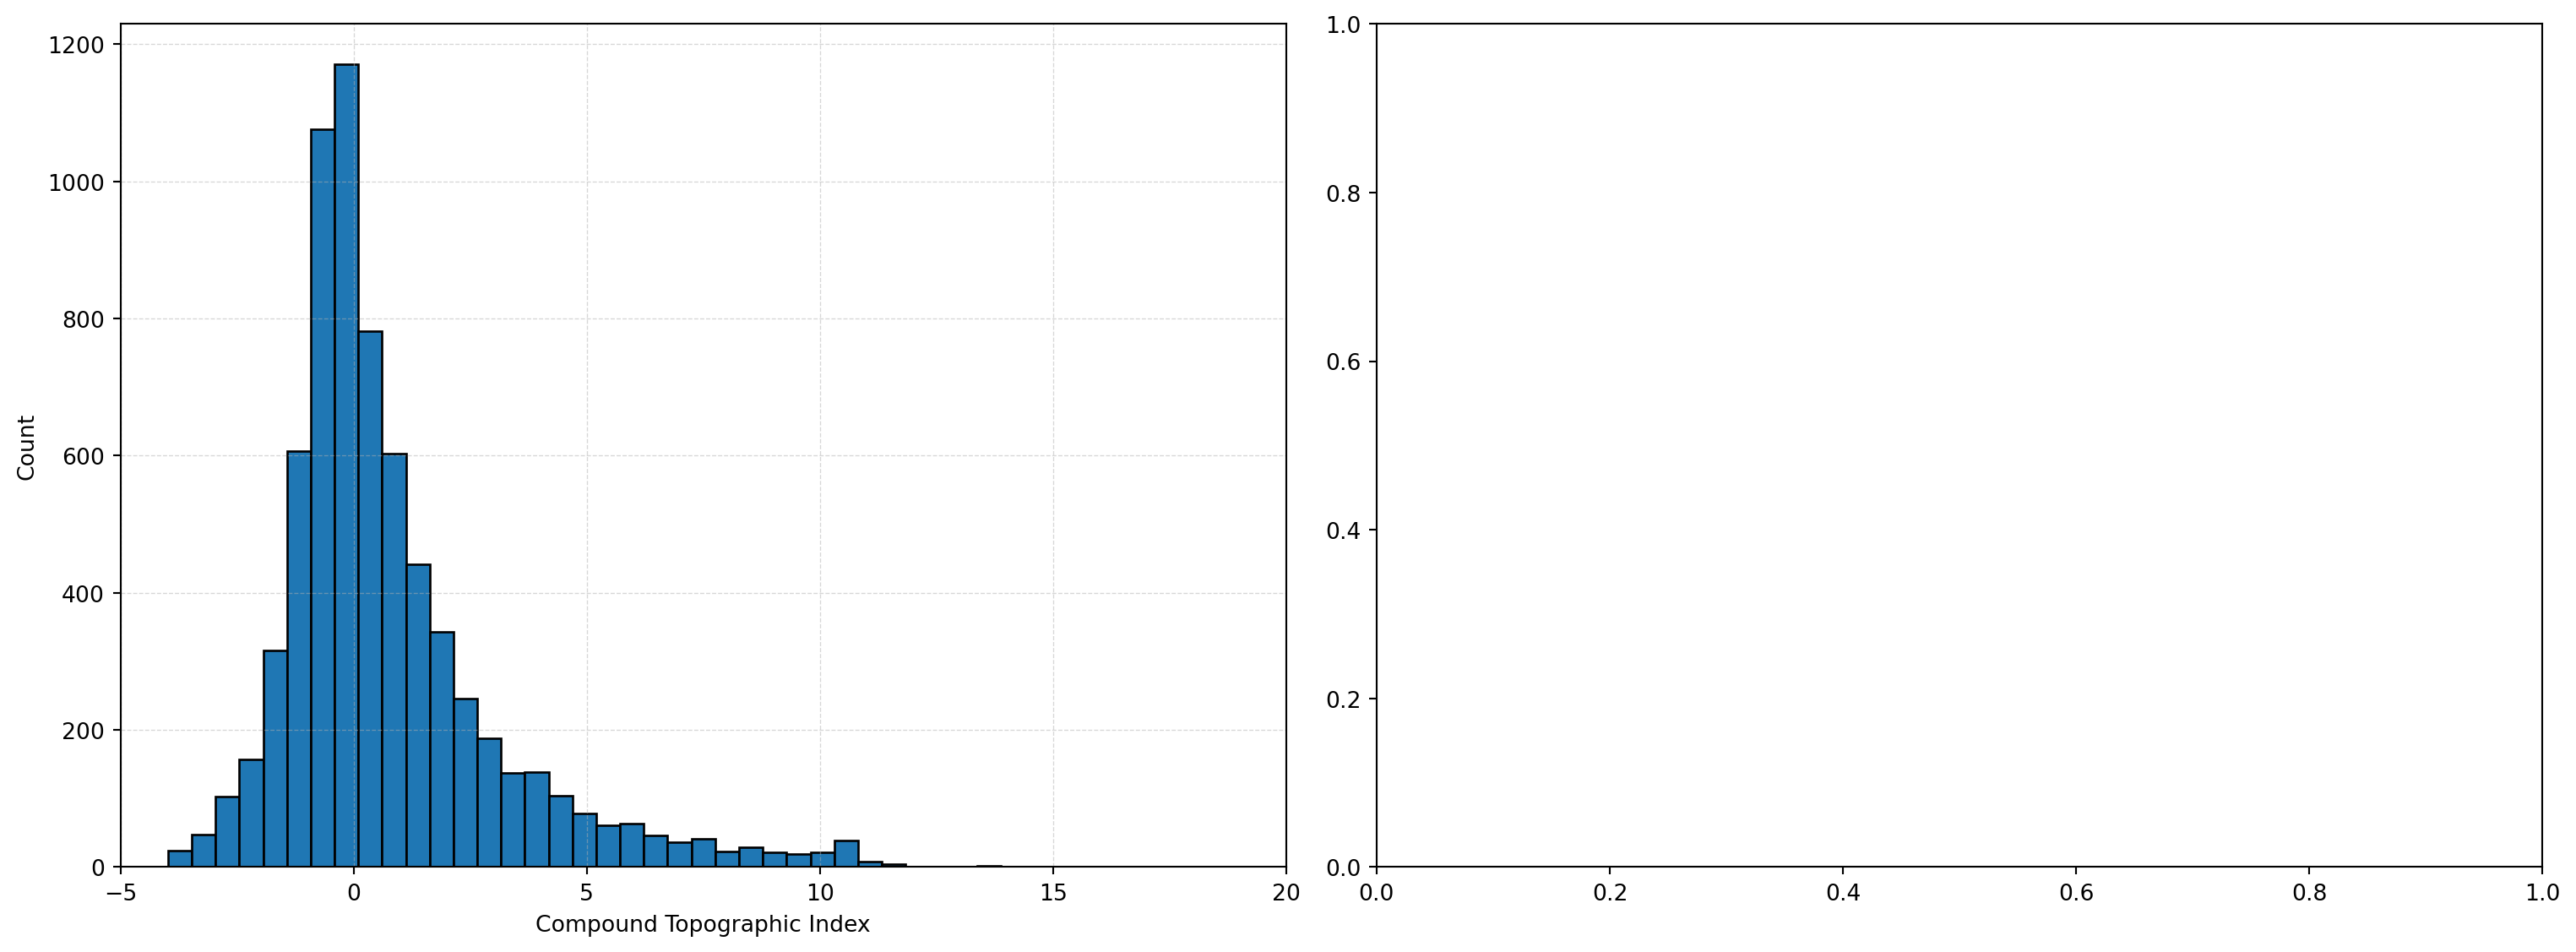

In [15]:
bins = np.linspace(-5, 20, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df.loc[~m, vs30.constants.InputVariable.CompoundTopgraphicIndex], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Compound Topographic Index")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

# ax2.hist(np.log(us_df.loc[~m, vs30.constants.InputVariable.CompoundTopgraphicIndex].values + 5 ), bins=25, edgecolor='black')
# ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
# ax2.set_xlabel("Ln(Compound Topographic Index)")
# ax2.set_ylabel("Count")


fig.tight_layout()

Not 100% how to pre-process this one yet

### Geomorphologic Phonotype

In [16]:
us_df[vs30.constants.InputVariable.Geomorphon].describe()

count    6989.000000
mean        2.927028
std         2.663508
min         0.000000
25%         1.000000
50%         1.000000
75%         6.000000
max        10.000000
Name: geomorphon, dtype: float64

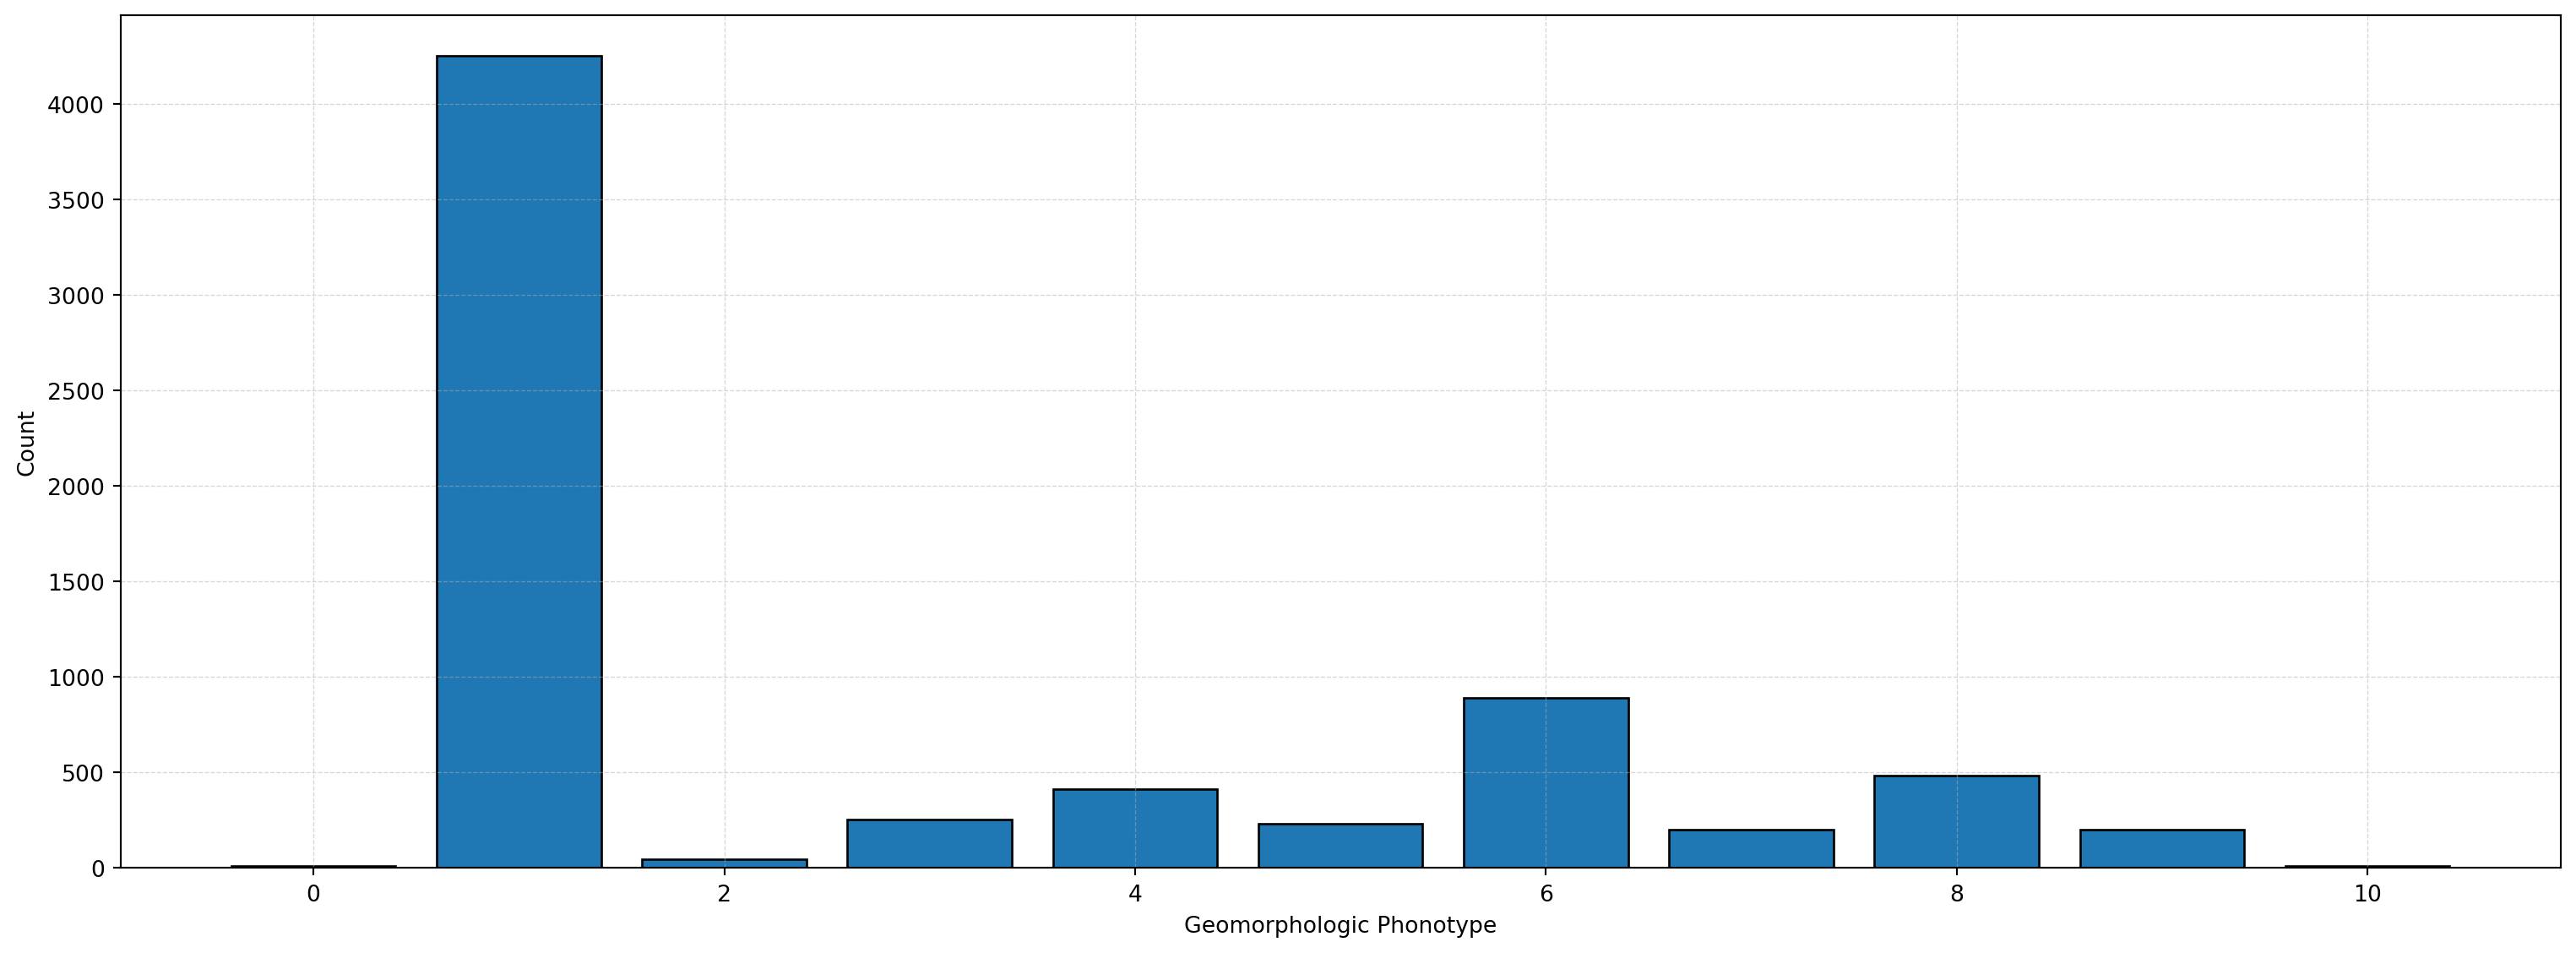

In [17]:
val_counts = us_df[vs30.constants.InputVariable.Geomorphon].value_counts()

fig, ax1 = plt.subplots(1, 1,figsize=(16, 6))


ax1.bar(val_counts.index, val_counts.values, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Geomorphologic Phonotype")
ax1.set_ylabel("Count")


fig.tight_layout()

Need to check if the order has meaning? Otherwise need to use one-hot encoding.  
Also, heavily biased towards type=1

### Topographic slope

In [18]:
var = vs30.constants.InputVariable.TopographicSlope
m = us_df[var] < -1000
us_df.loc[~m, var].describe()

count    6980.000000
mean        1.426962
std         2.520489
min         0.004315
25%         0.233586
50%         0.593615
75%         1.410300
max        29.405689
Name: topographic_slope, dtype: float64

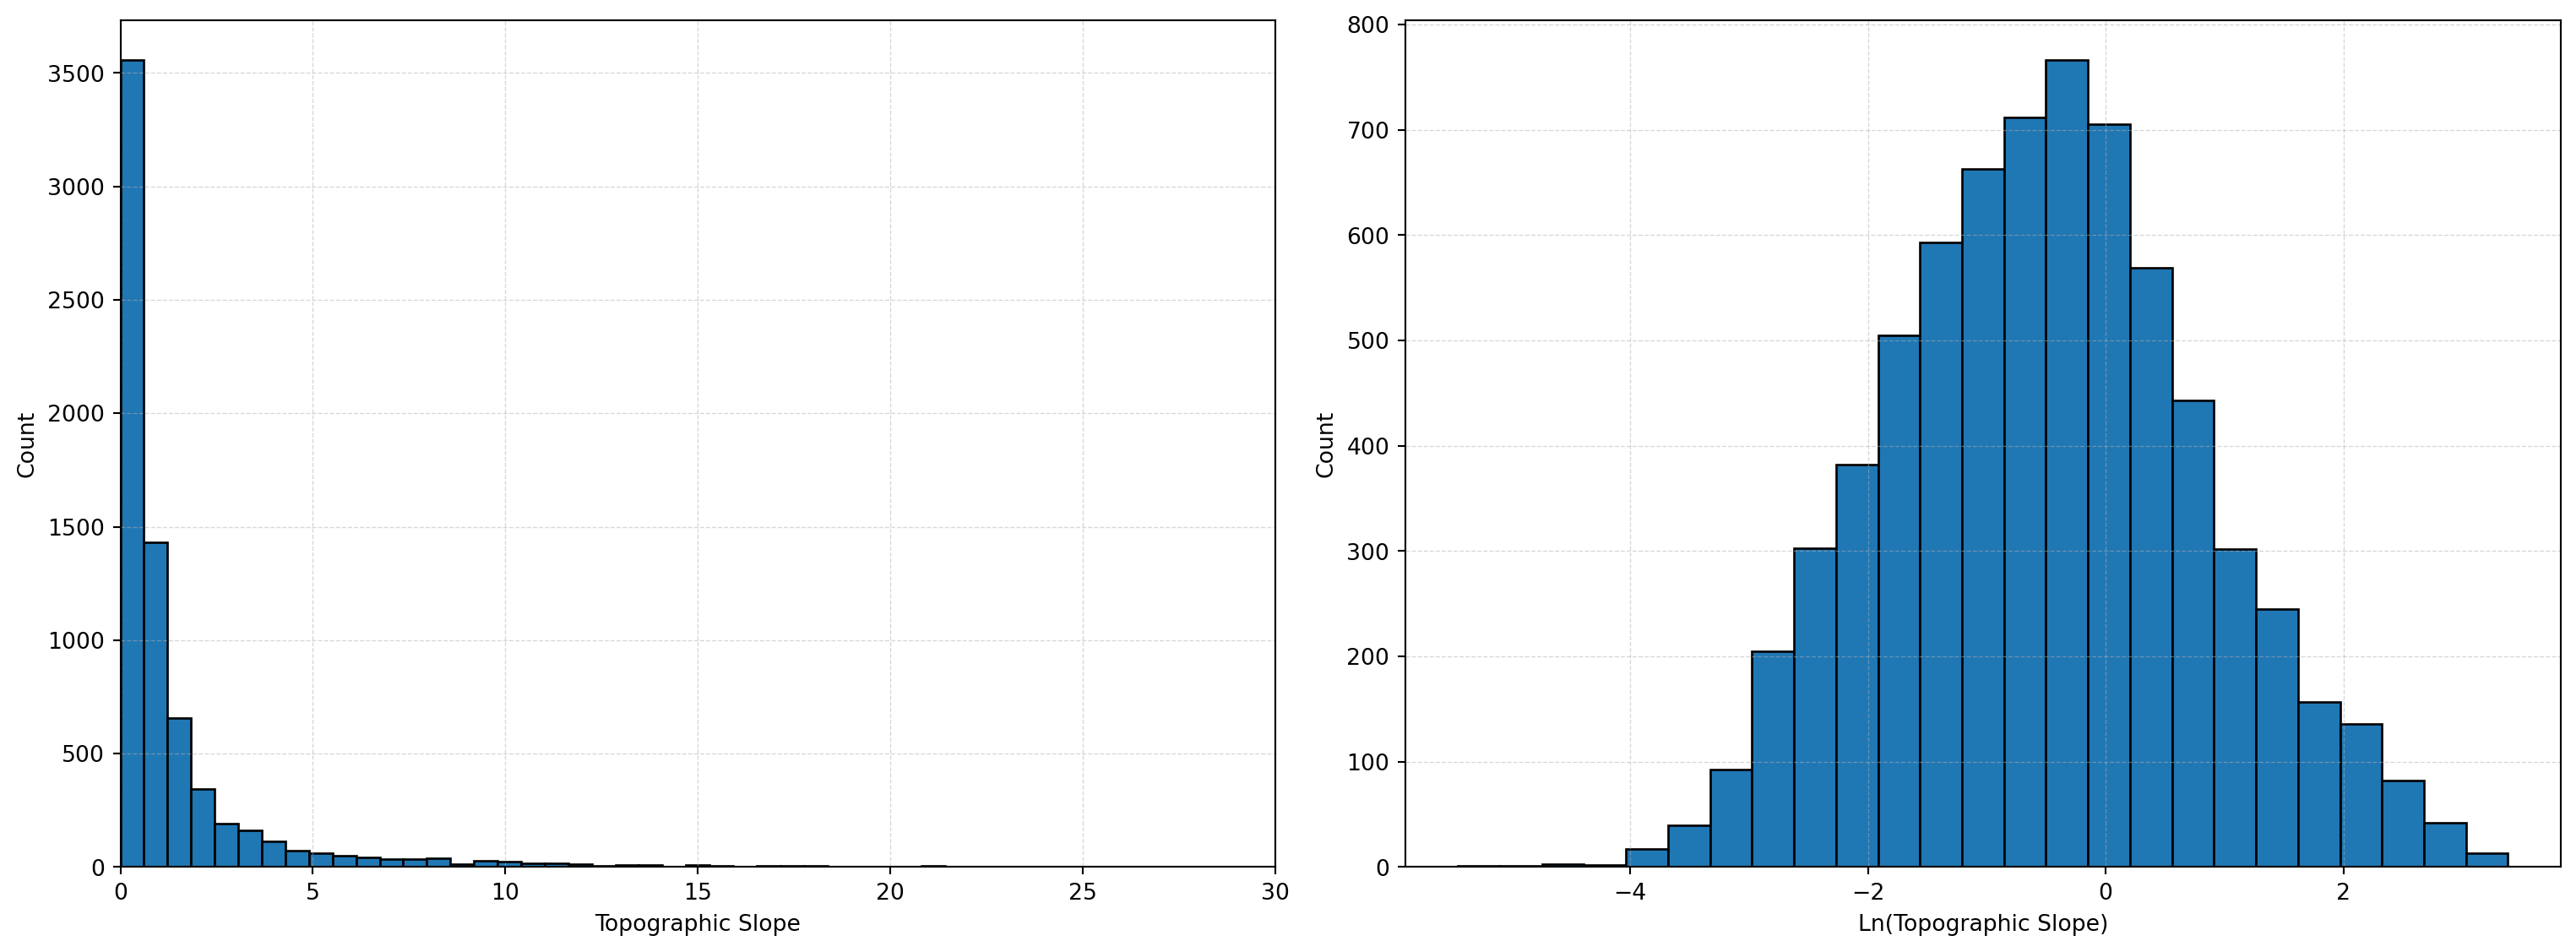

In [19]:
bins = np.linspace(0, 30, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df.loc[~m, var], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Topographic Slope")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

ax2.hist(np.log(us_df.loc[~m, var].values), bins=25, edgecolor='black')
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Ln(Topographic Slope)")
ax2.set_ylabel("Count")


fig.tight_layout()

Log-transform + z-norm seems like a good option

### Topographic Position Index

In [20]:
var = vs30.constants.InputVariable.TopographicPositionIndex
m = us_df[var] < -1000
us_df.loc[~m,var].describe()

count    6980.000000
mean        0.092490
std         1.994326
min       -21.614422
25%        -0.302019
50%         0.001635
75%         0.283048
max        25.877964
Name: topographic_position_index, dtype: float64

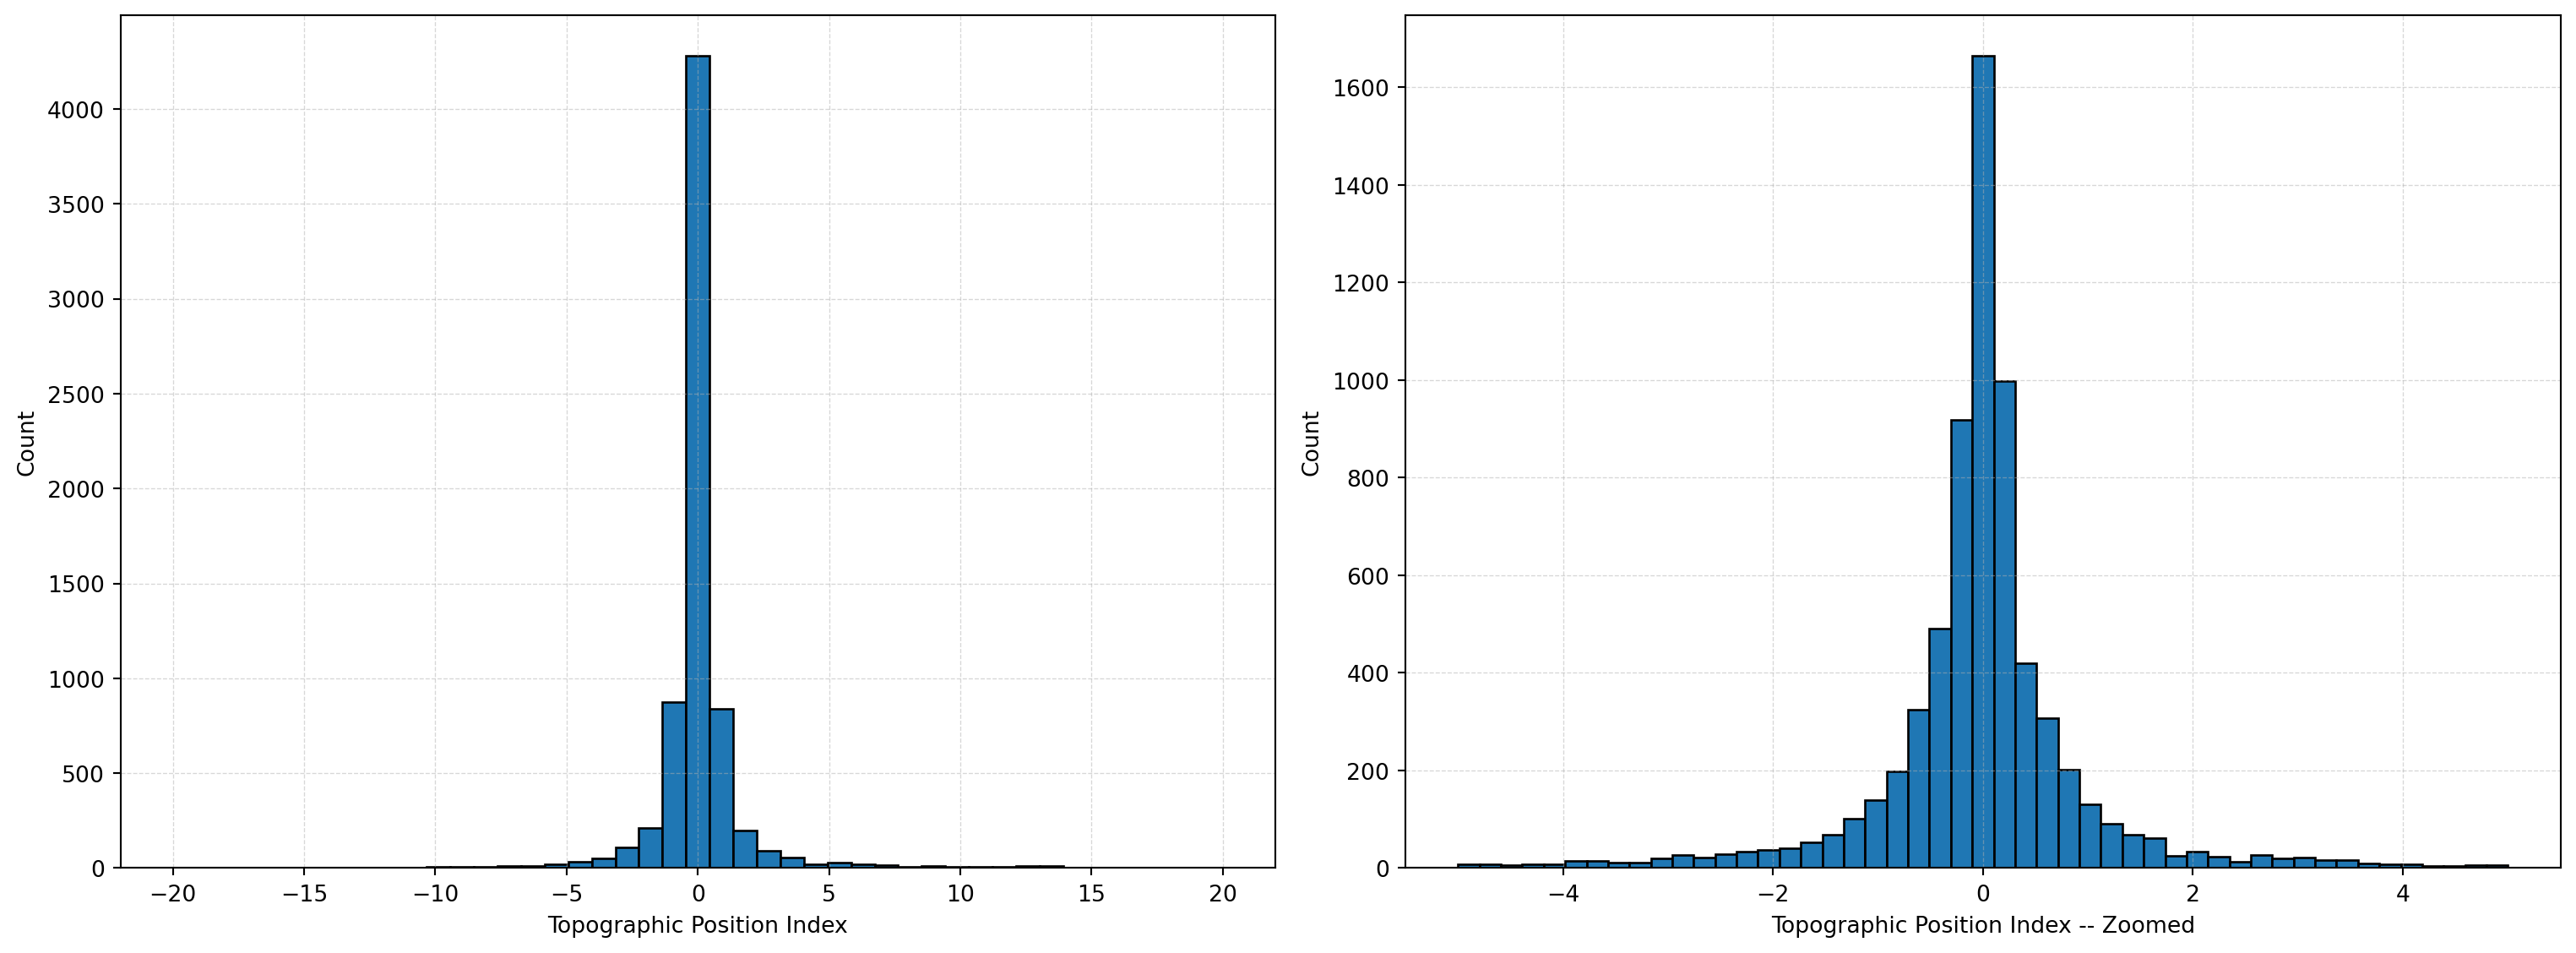

In [21]:
bins = np.linspace(-22, 22, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df.loc[~m, var], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Topographic Position Index")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

ax2.hist(us_df.loc[~m, var].values, bins=np.linspace(-5, 5, 50), edgecolor='black')
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Topographic Position Index -- Zoomed")
ax2.set_ylabel("Count")

fig.tight_layout()

Just Z-Norm should be fine

### Profile Curvature

In [22]:
var = vs30.constants.InputVariable.ProfileCurvature
m = us_df[var] < -1000
us_df.loc[~m, var].describe()

count    6.980000e+03
mean    -1.991552e-07
std      3.196538e-04
min     -2.909567e-03
25%     -5.350323e-05
50%     -2.192706e-07
75%      4.660786e-05
max      3.898997e-03
Name: profile_curvature, dtype: float64

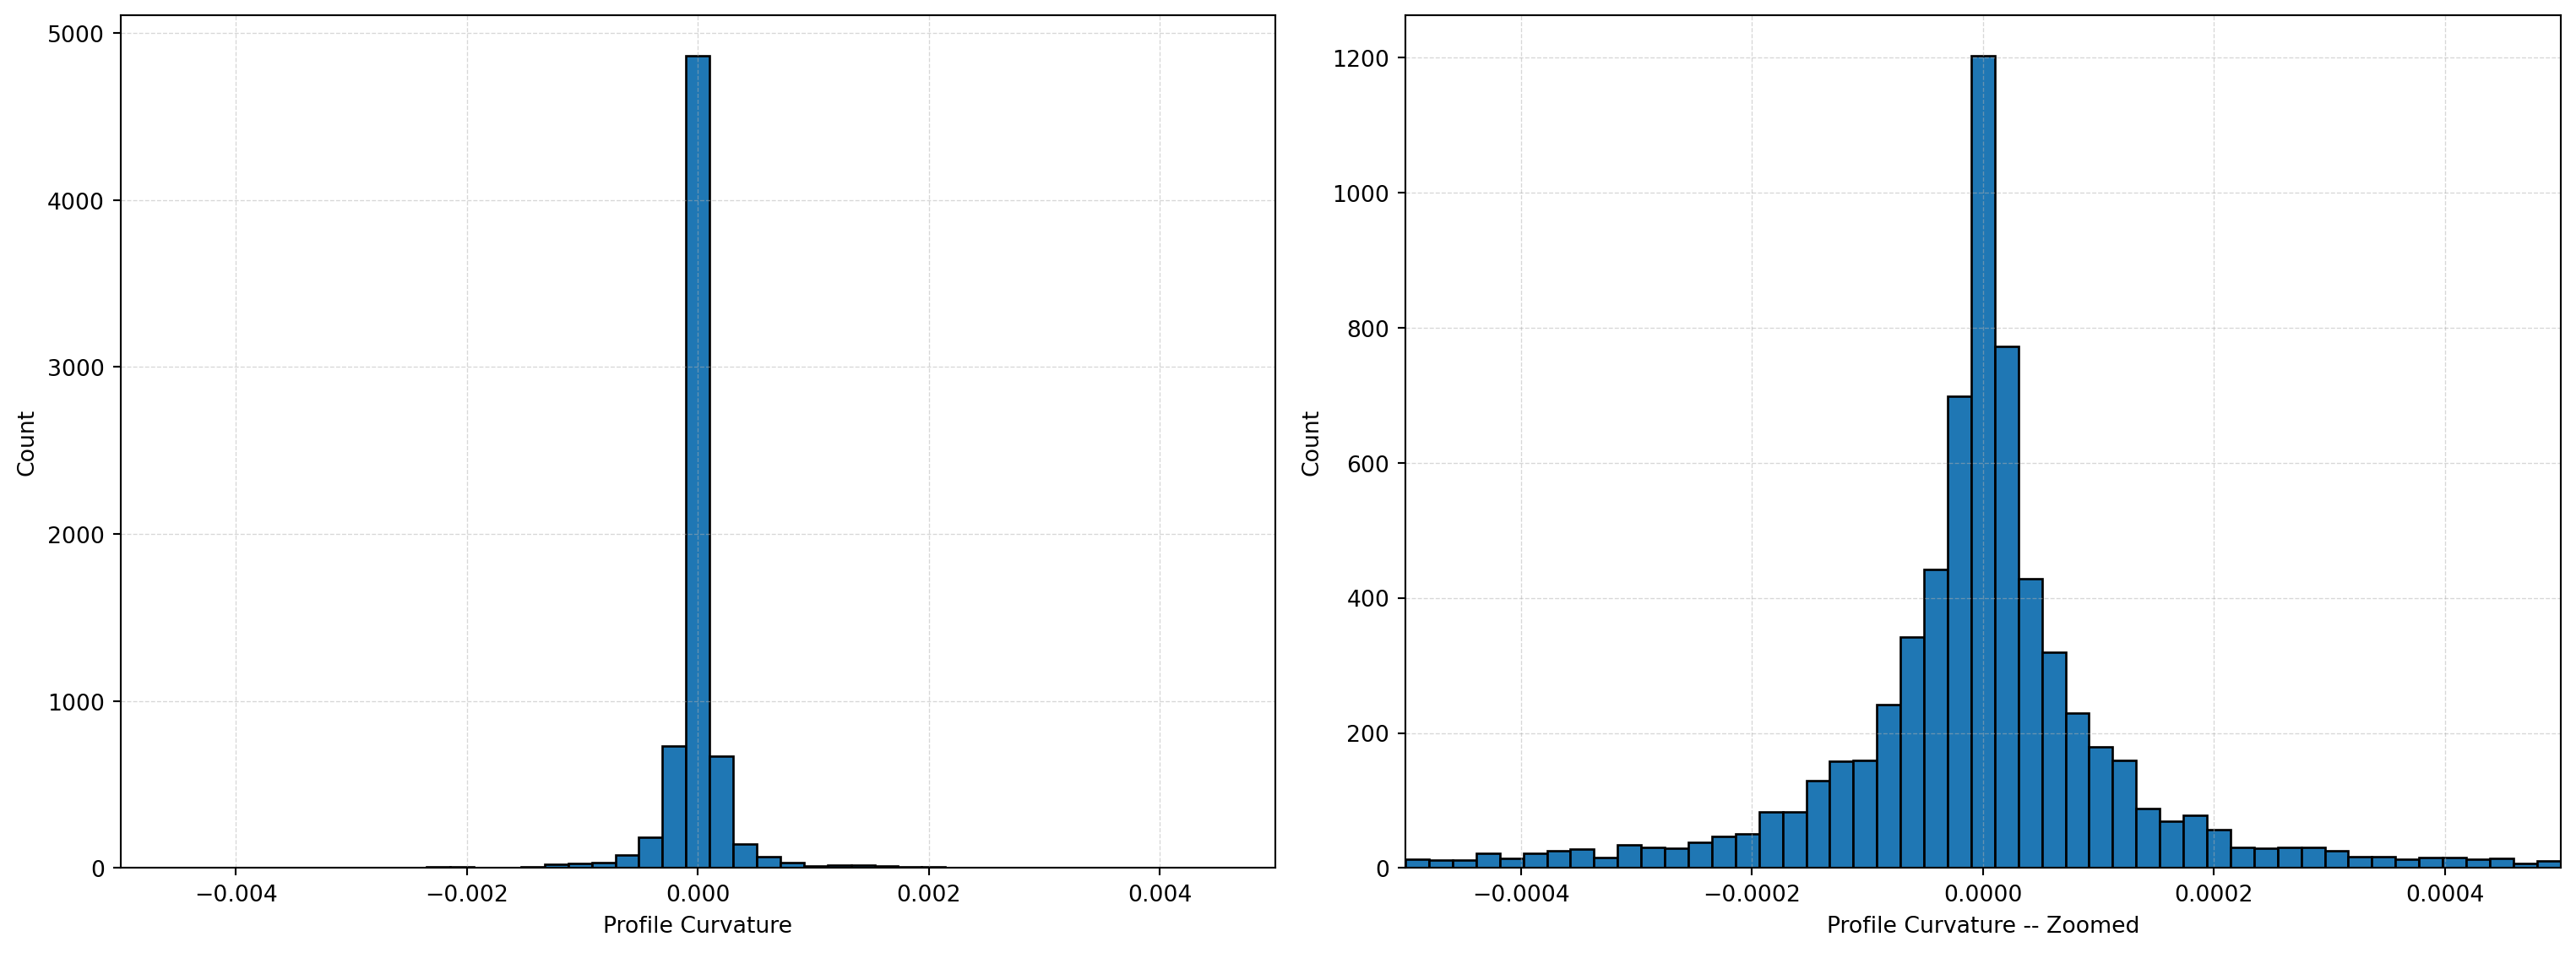

In [23]:
bins = np.linspace(-0.005, 0.005, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df.loc[~m, var], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Profile Curvature")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

bins = np.linspace(-0.0005, 0.0005, 50)
ax2.hist(us_df.loc[~m, var].values, bins=bins, edgecolor='black')
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Profile Curvature -- Zoomed")
ax2.set_ylabel("Count")
ax2.set_xlim(bins.min(), bins.max())

fig.tight_layout()

Again, Z-Norm

### Tangential Curvature

In [24]:
var = vs30.constants.InputVariable.TangentialCurvature
m = us_df[var] < -1000
us_df.loc[~m, var].describe()

count    6980.000000
mean        0.000024
std         0.000268
min        -0.002955
25%        -0.000039
50%         0.000002
75%         0.000046
max         0.003738
Name: tangential_curvature, dtype: float64

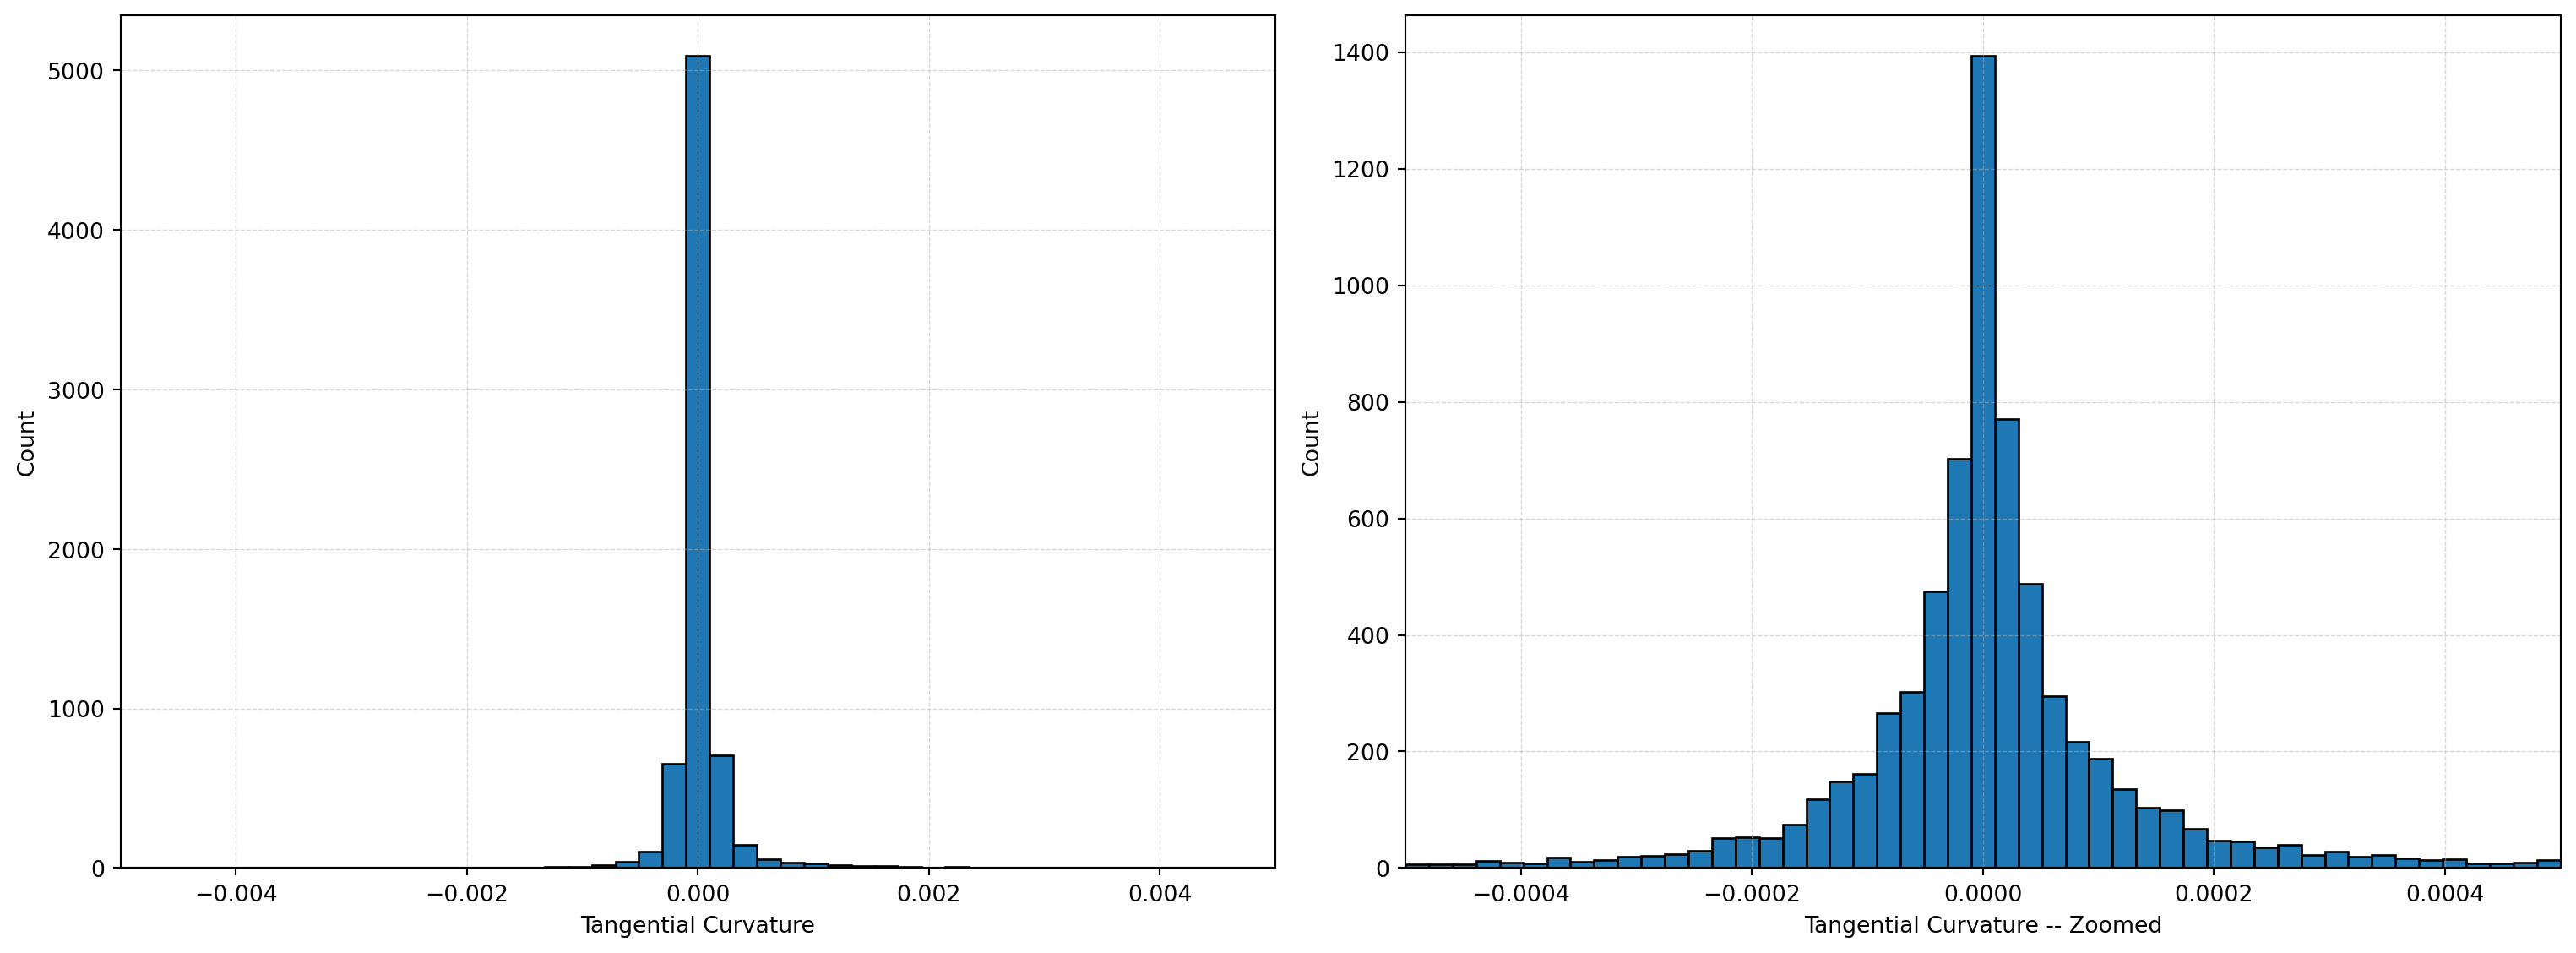

In [25]:
bins = np.linspace(-0.005, 0.005, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df.loc[~m, var], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Tangential Curvature")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

bins = np.linspace(-0.0005, 0.0005, 50)
ax2.hist(us_df.loc[~m, var].values, bins=bins, edgecolor='black')
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Tangential Curvature -- Zoomed")
ax2.set_ylabel("Count")
ax2.set_xlim(bins.min(), bins.max())

fig.tight_layout()

Z-Norm

### Roughness

In [26]:
var = vs30.constants.InputVariable.Roughness
m = us_df[var] < -1000
us_df.loc[~m, var].describe()

count    6980.000000
mean        7.231198
std        12.208035
min         0.021294
25%         1.407082
50%         3.327110
75%         6.920727
max       142.895844
Name: roughness, dtype: float64

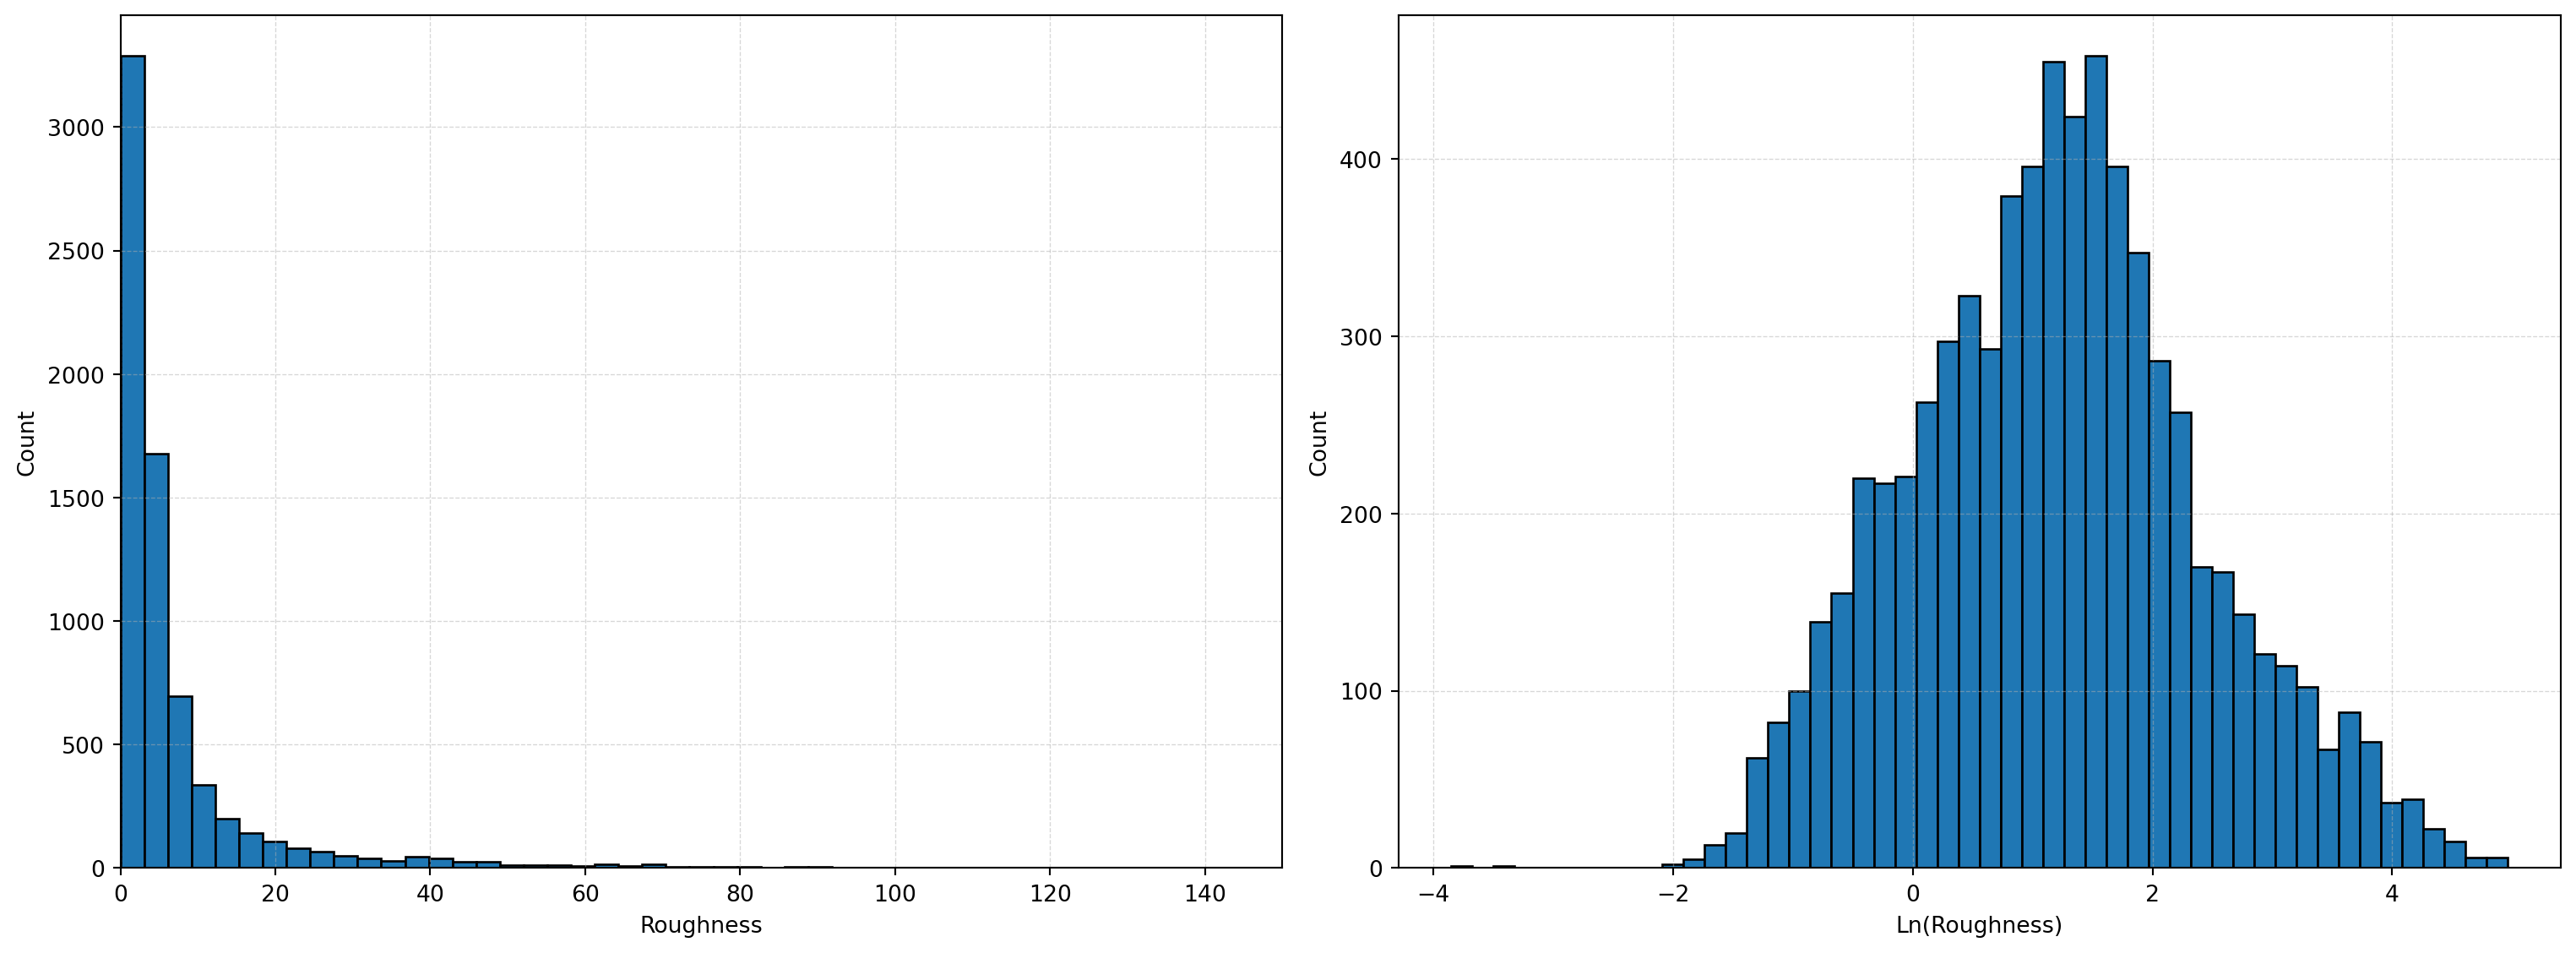

In [27]:
bins = np.linspace(0, 150, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df.loc[~m, var], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Roughness")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

# bins = np.linspace(-0.0005, 0.0005, 50)
bins = 50
ax2.hist(np.log(us_df.loc[~m, var].values), bins=bins, edgecolor='black')
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Ln(Roughness)")
ax2.set_ylabel("Count")
# ax2.set_xlim(bins.min(), bins.max())

fig.tight_layout()

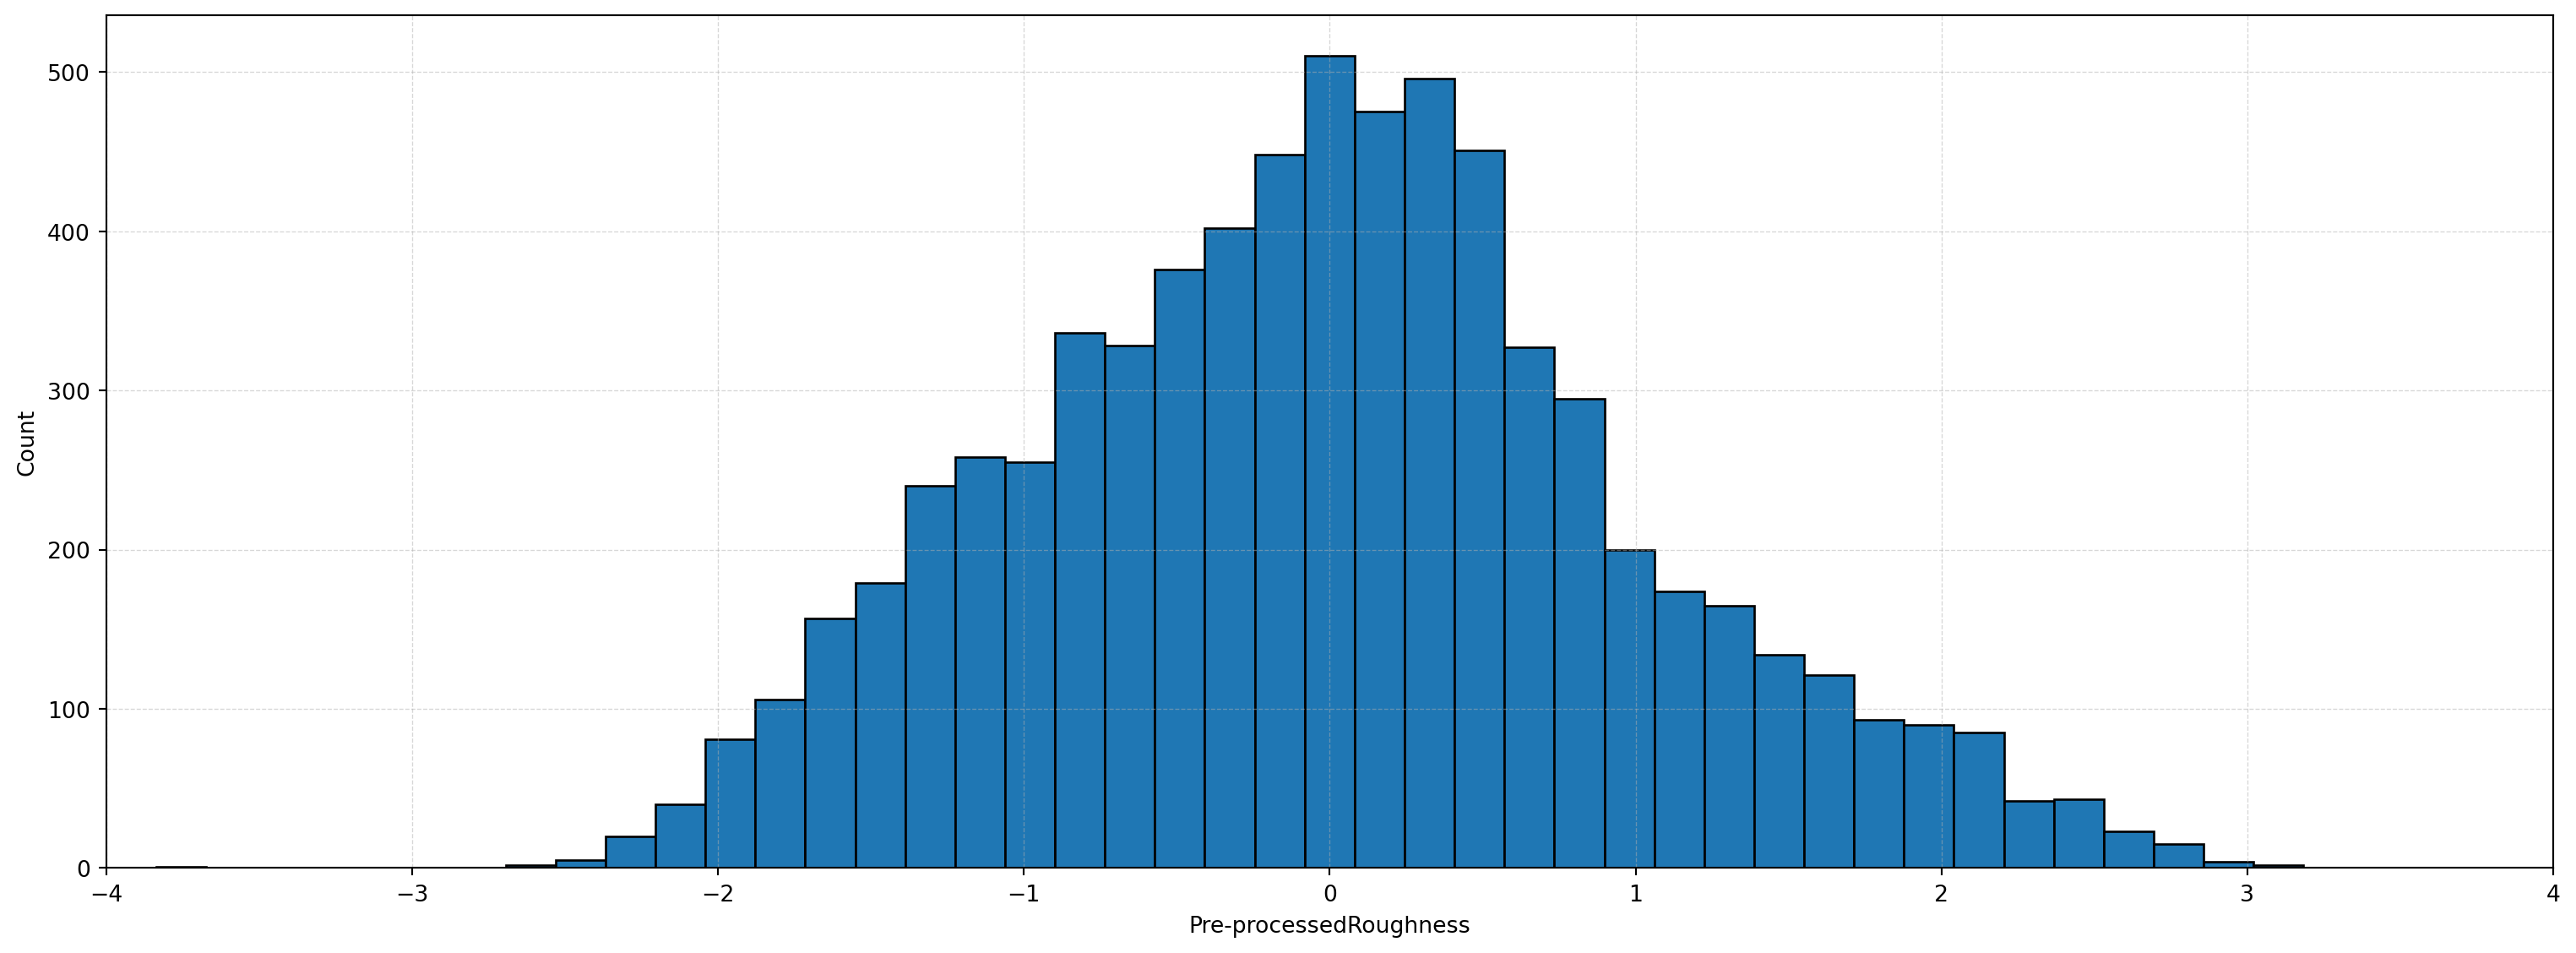

In [28]:
bins = np.linspace(-4, 4, 50)
# bins=50

fig, ax1 = plt.subplots(1, 1,figsize=(16, 6))

values = np.log(us_df.loc[~m, var])
std_values = (values - values.mean()) / values.std()

ax1.hist(std_values, bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Pre-processedRoughness")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

fig.tight_layout()

Log transform + Z-norm

### Terrain Ruggedness Index

In [29]:
var = vs30.constants.InputVariable.TerrainRuggednessIndex
m = us_df[var] < -1000
us_df.loc[~m, var].describe()

count    6980.000000
mean        2.294580
std         3.837016
min         0.005356
25%         0.459231
50%         1.079546
75%         2.283708
max        47.102016
Name: terrain_ruggedness_index, dtype: float64

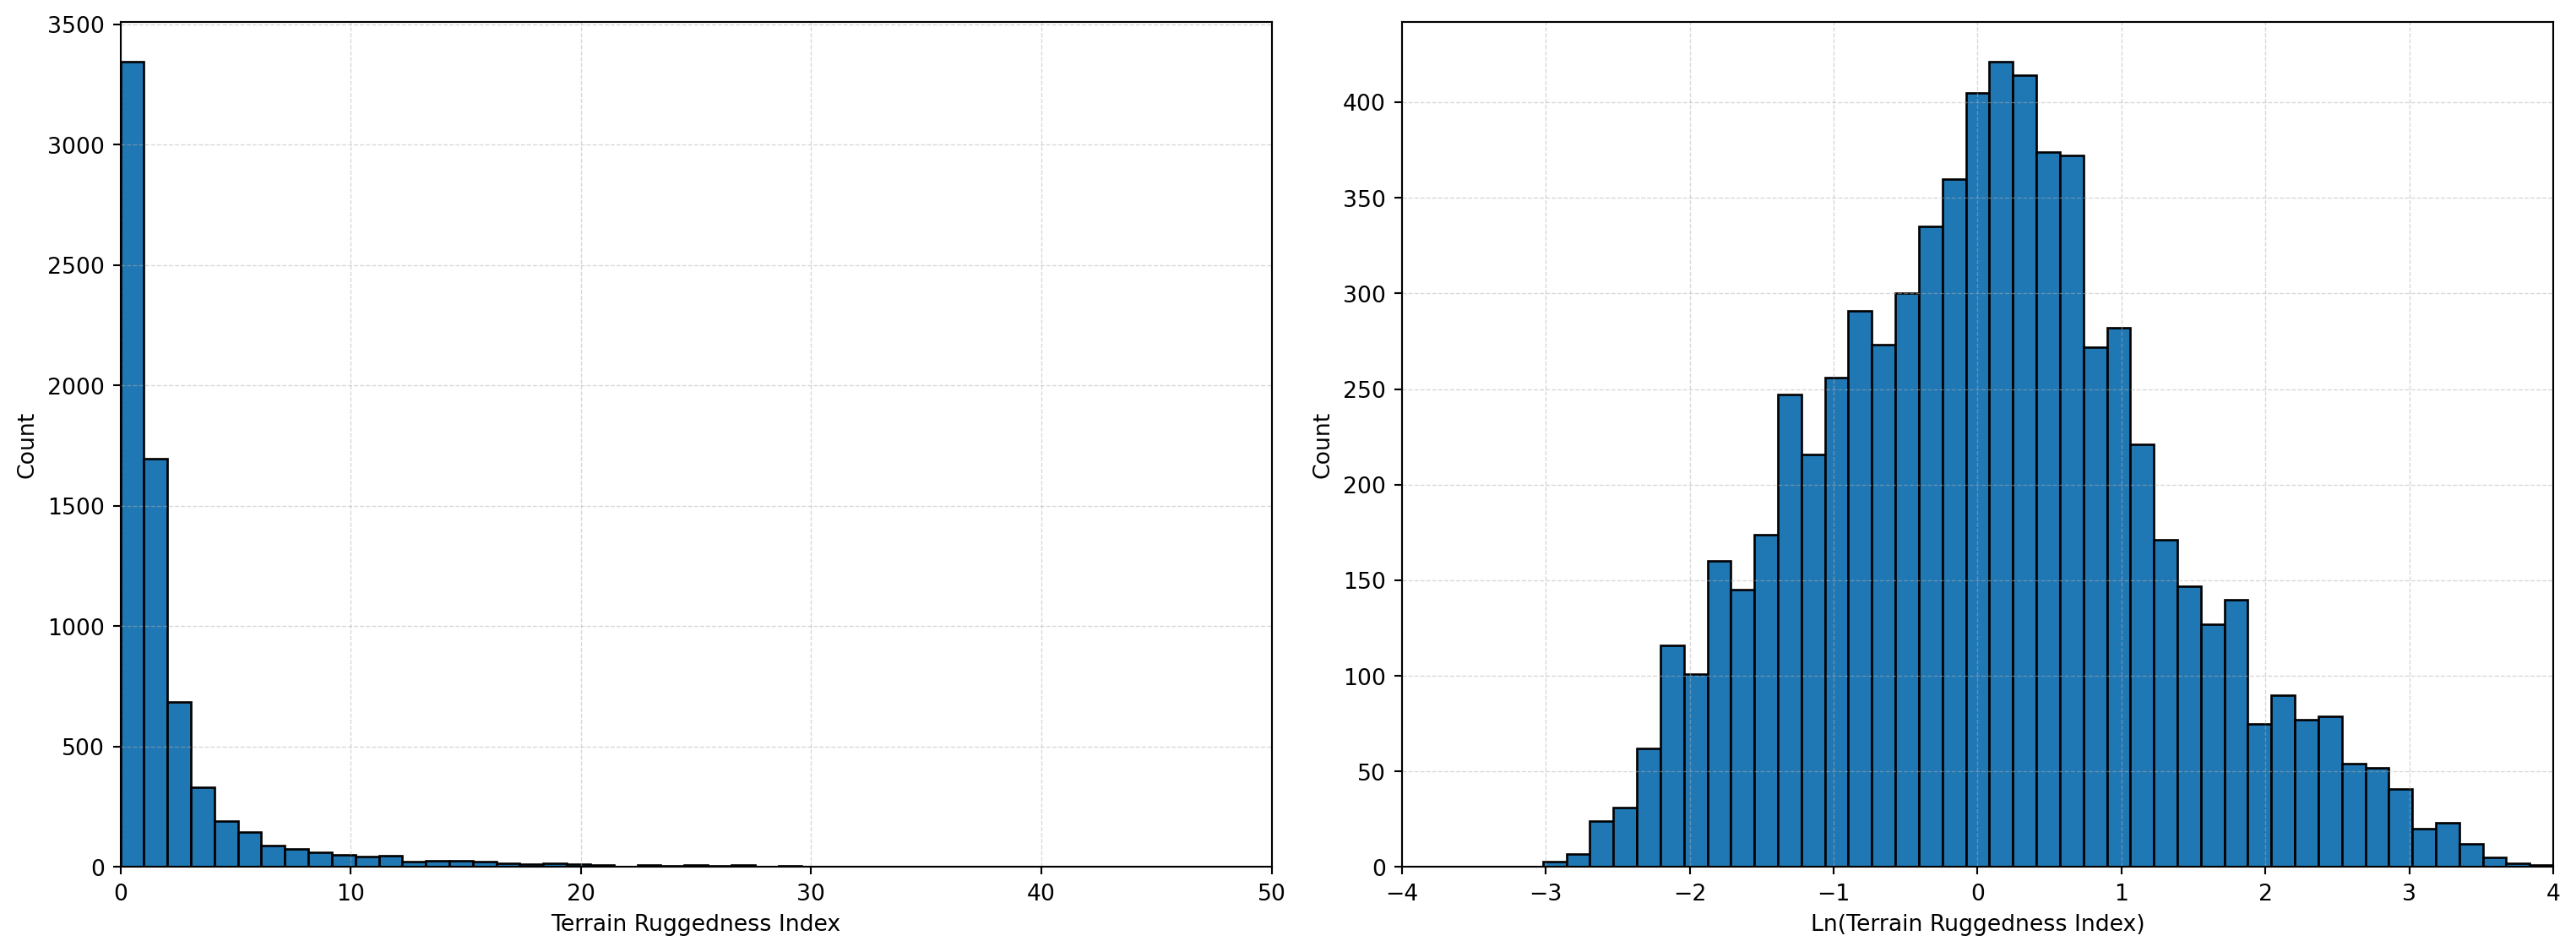

In [30]:
bins = np.linspace(0, 50, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df.loc[~m, var], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Terrain Ruggedness Index")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

bins = np.linspace(-4, 4, 50)
# bins = 50
ax2.hist(np.log(us_df.loc[~m, var].values), bins=bins, edgecolor='black')
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Ln(Terrain Ruggedness Index)")
ax2.set_ylabel("Count")
ax2.set_xlim(bins.min(), bins.max())

fig.tight_layout()

Log-transform + z-norm

### Vector Ruggedness Measure

In [31]:
var = vs30.constants.InputVariable.VectorRuggednessMeasure
m = us_df[var] < -1000
us_df.loc[~m, var].describe()

count    6.980000e+03
mean     4.843797e-04
std      2.268396e-03
min      2.454654e-09
25%      5.085574e-06
50%      2.241778e-05
75%      9.998613e-05
max      5.328881e-02
Name: vector_ruggedness_measure, dtype: float64

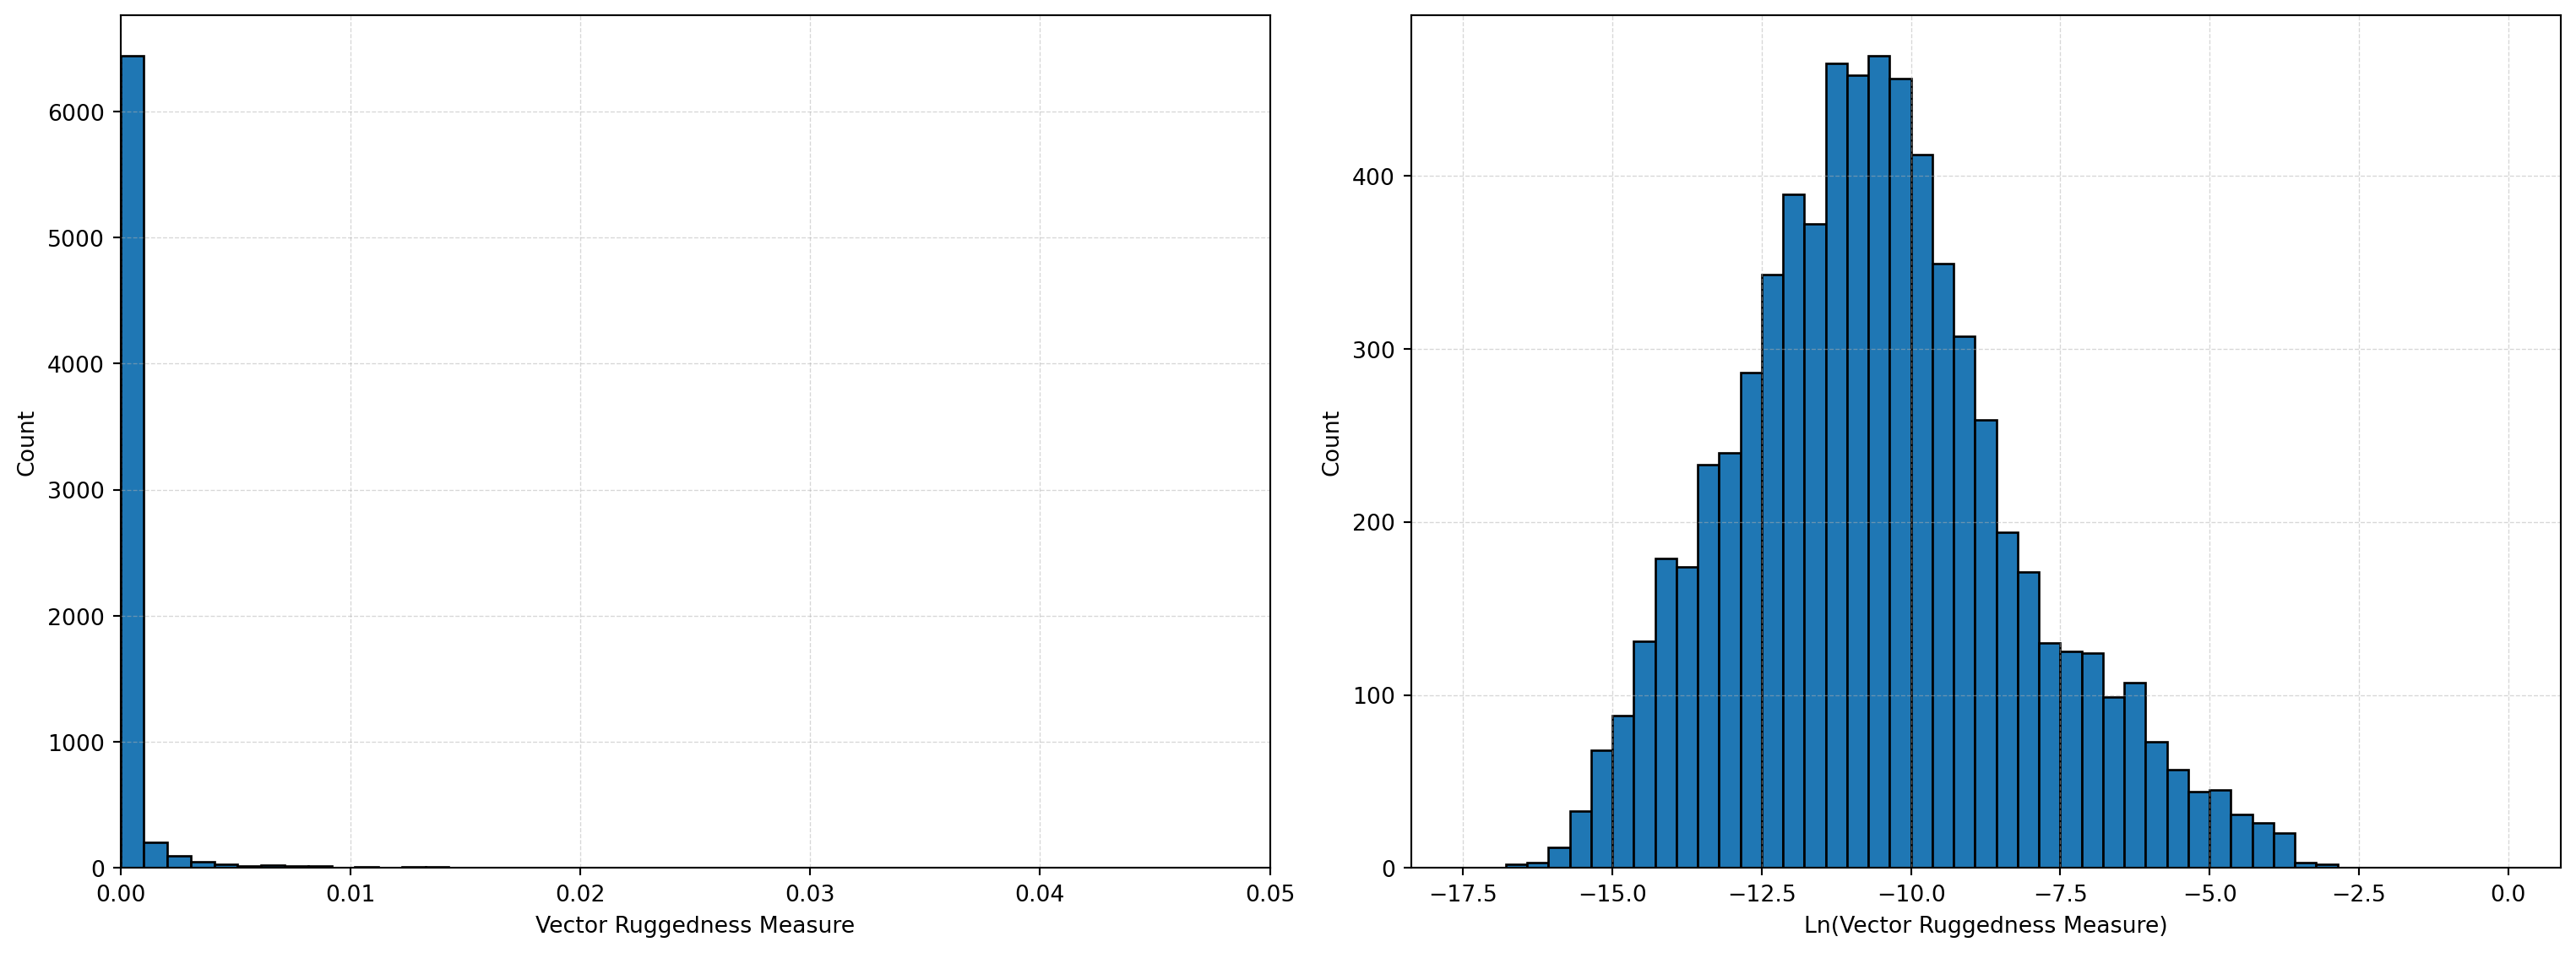

In [32]:
bins = np.linspace(0.0, 0.05, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df.loc[~m, var], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Vector Ruggedness Measure")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

bins = np.linspace(-17.5, 0, 50)
# bins = 50
ax2.hist(np.log(us_df.loc[~m, var].values), bins=bins, edgecolor='black')
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Ln(Vector Ruggedness Measure)")
ax2.set_ylabel("Count")
# ax2.set_xlim(bins.min(), bins.max())

fig.tight_layout()

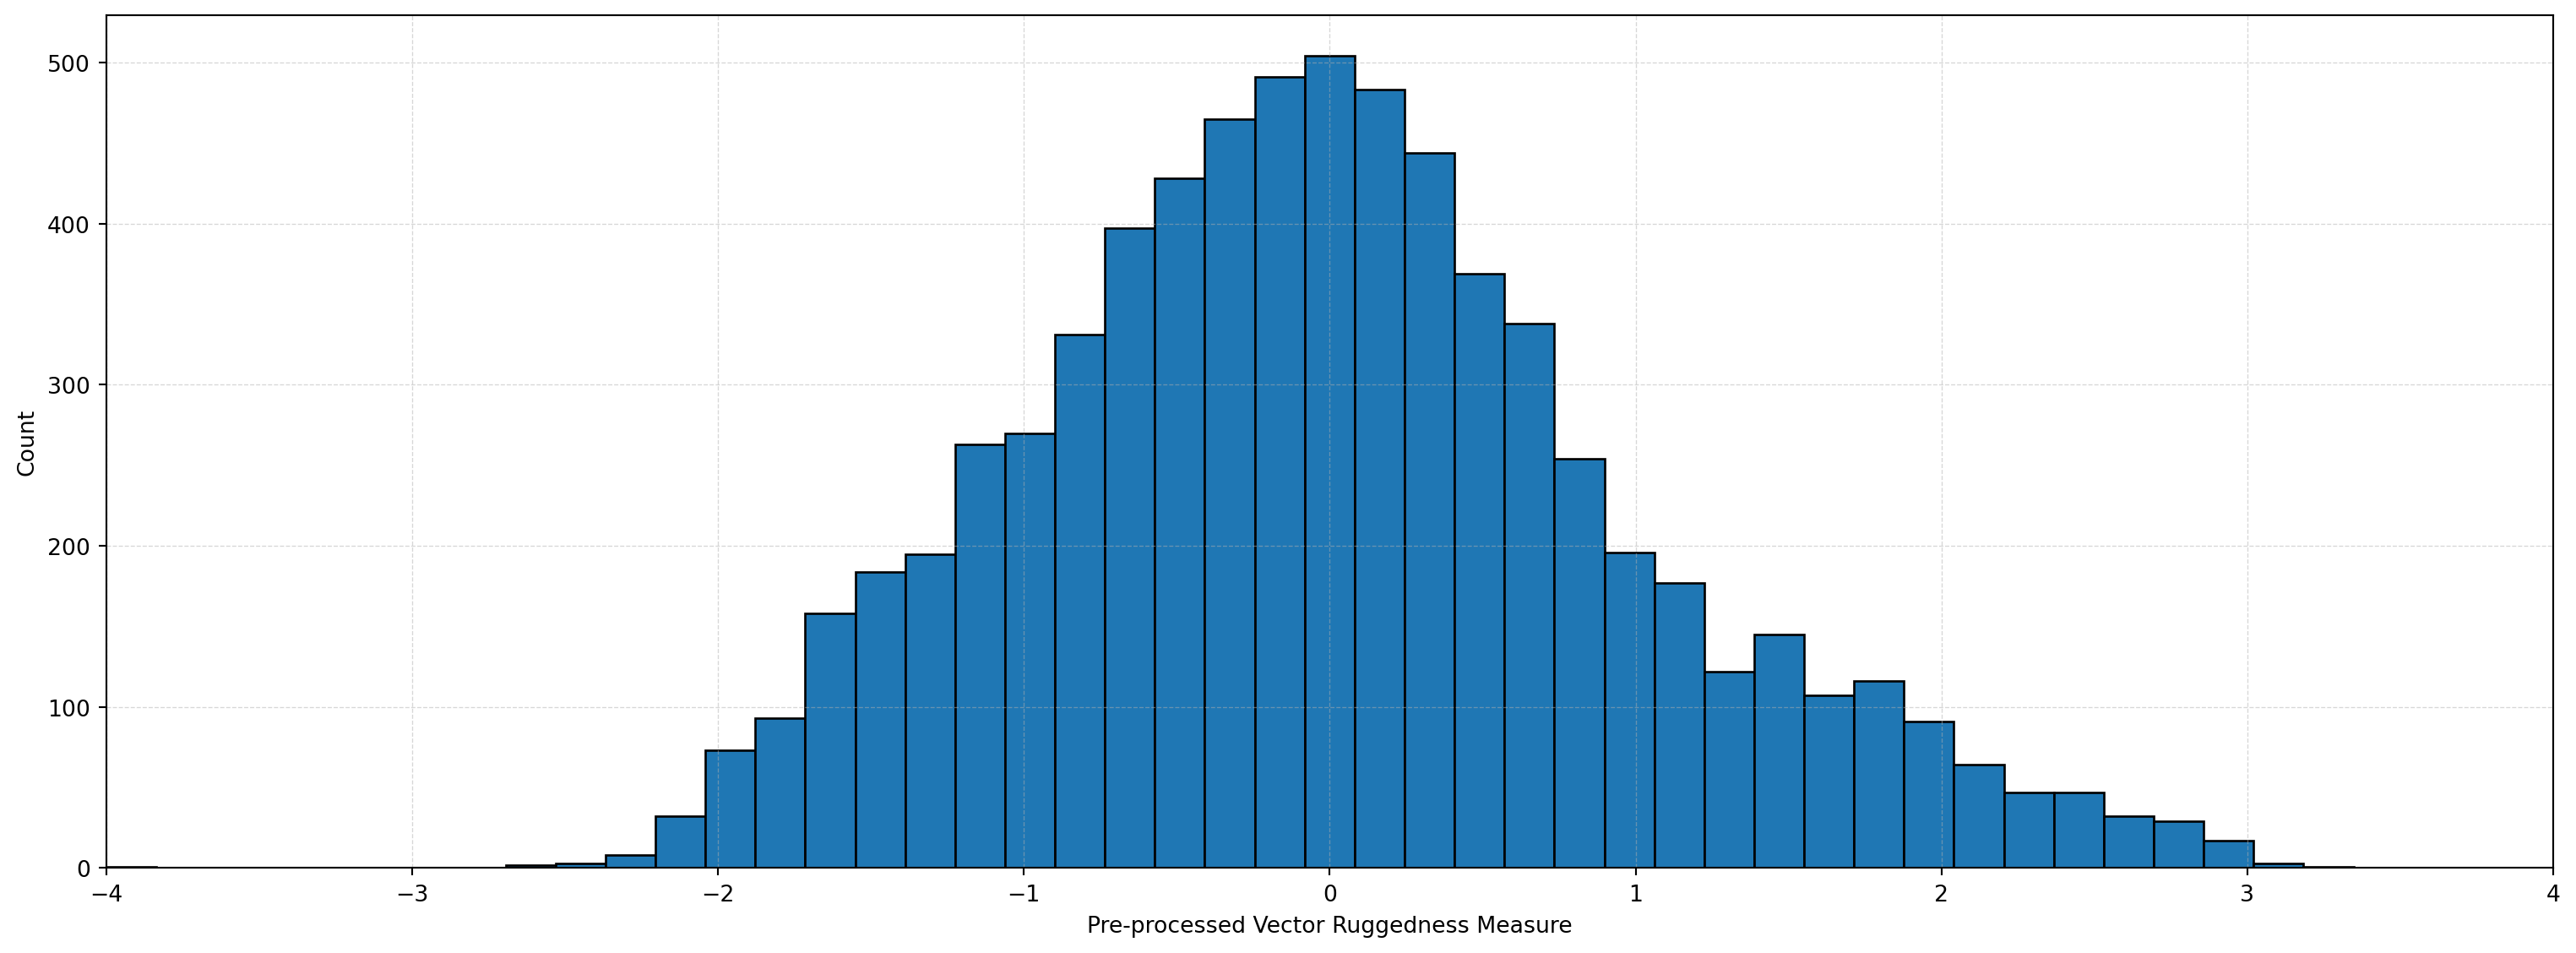

In [33]:
bins = np.linspace(-4, 4, 50)
# bins=50

fig, ax1 = plt.subplots(1, 1,figsize=(16, 6))

values = np.log(us_df.loc[~m, var])
std_values = (values - values.mean()) / values.std()

ax1.hist(std_values, bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Pre-processed Vector Ruggedness Measure")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

fig.tight_layout()

Log-transform + z-norm

### Landform Entropy

In [34]:
var = vs30.constants.InputVariable.LandformEntropy
us_df[var].describe()

count    6989.000000
mean        1.003706
std         0.982157
min        -0.000000
25%         0.000000
50%         0.763280
75%         2.010580
max         2.957196
Name: landform_entropy, dtype: float64

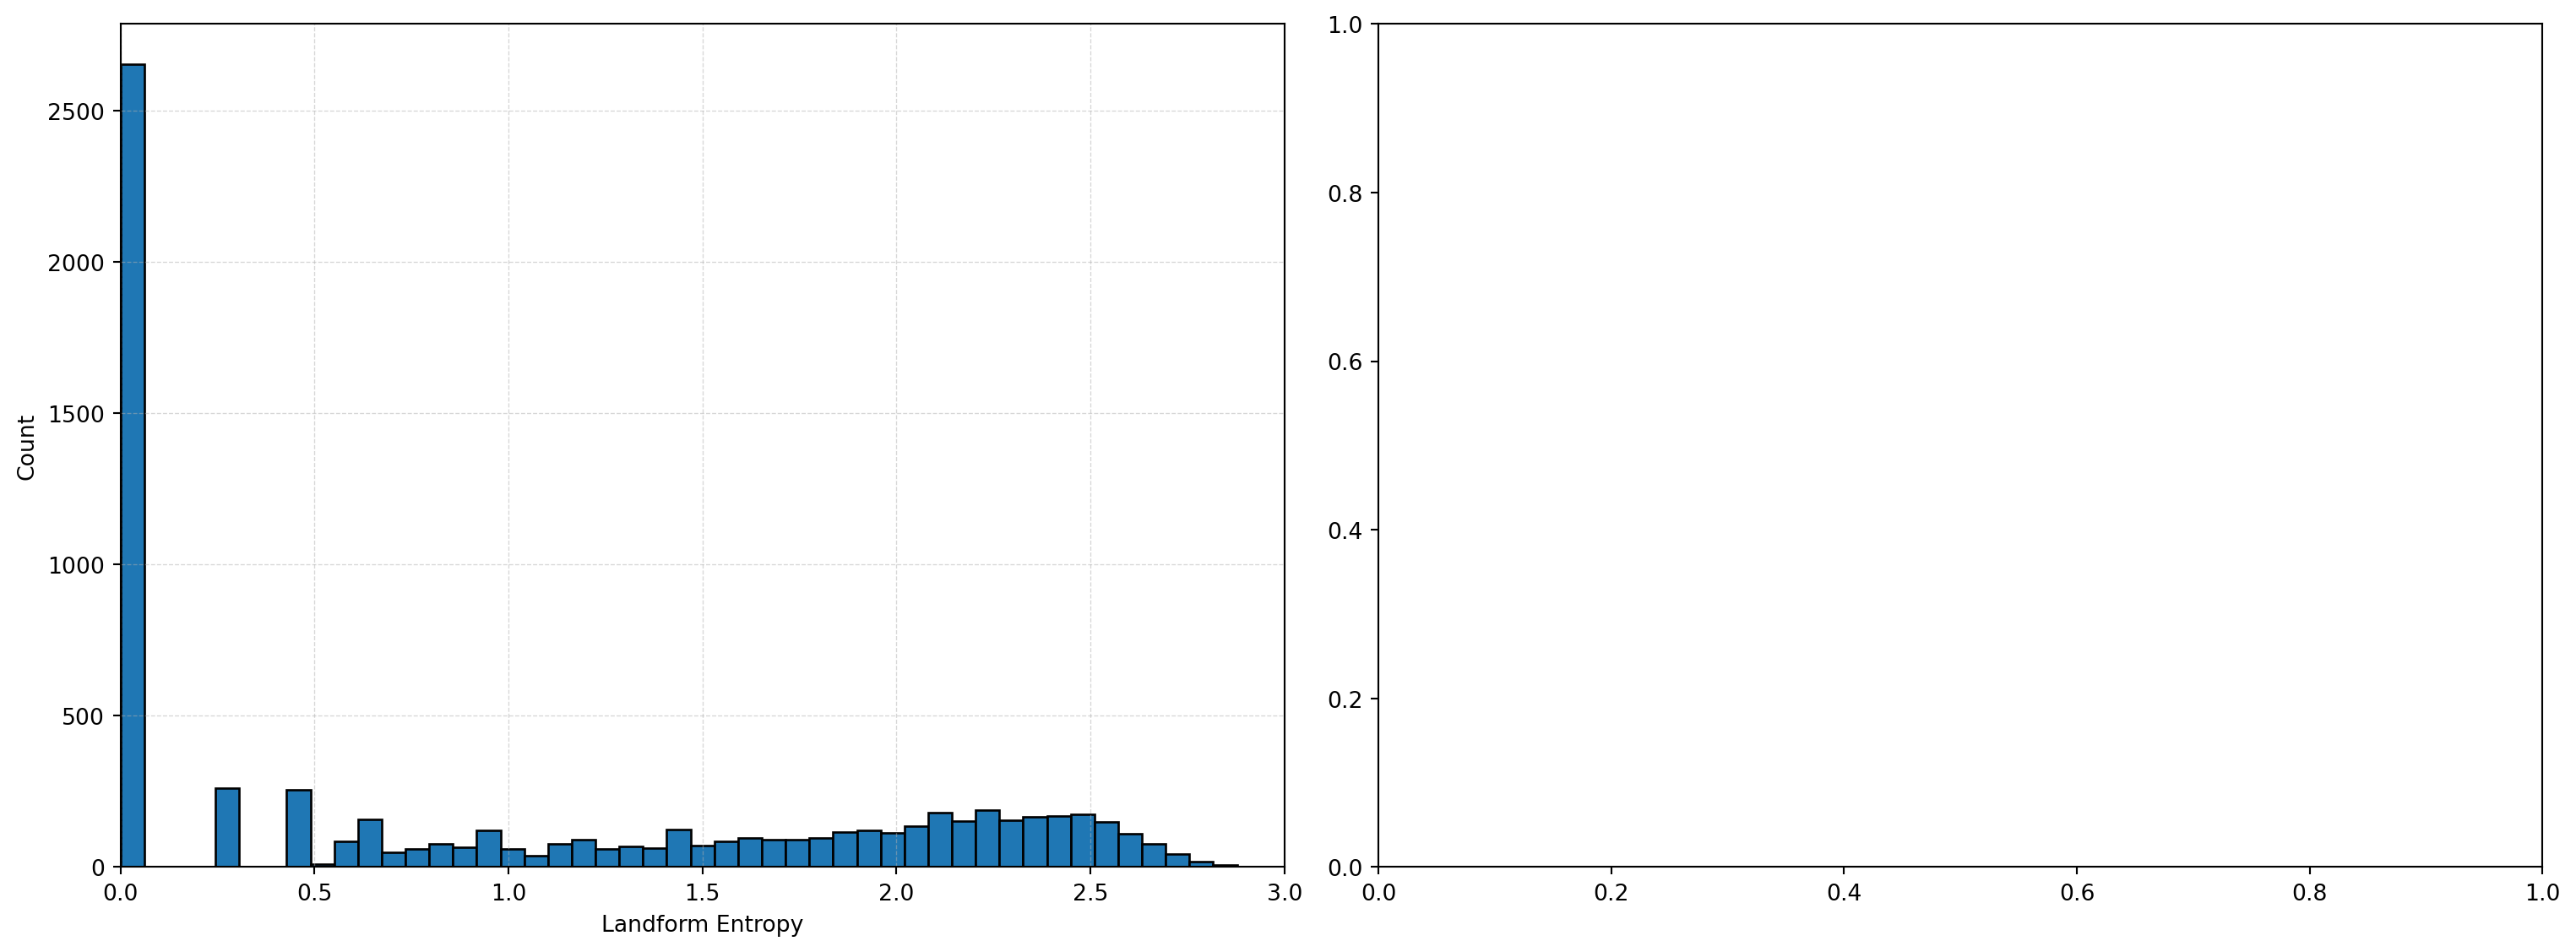

In [35]:
bins = np.linspace(0, 3, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df[var], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Landform Entropy")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

# bins = np.linspace(-0.0005, 0.0005, 50)
# bins = 50
# ax2.hist(np.log(np.where(us_df[var].values <= 0, 0.00001, us_df[var].values).min()), bins=bins, edgecolor='black')
# ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
# ax2.set_xlabel("Ln(Landform Entropy)")
# ax2.set_ylabel("Count")
# # ax2.set_xlim(bins.min(), bins.max())

fig.tight_layout()

Hmh not sure on this one. Maybe just simple min-max scaling. But whats the max value? Check the tif file.

### Landform Uniformity

In [36]:
var = vs30.constants.InputVariable.LandformUniformity
us_df[var].describe()

count    6989.000000
mean        0.587519
std         0.380757
min         0.053627
25%         0.169657
50%         0.627218
75%         1.000000
max         1.000000
Name: landform_uniformity, dtype: float64

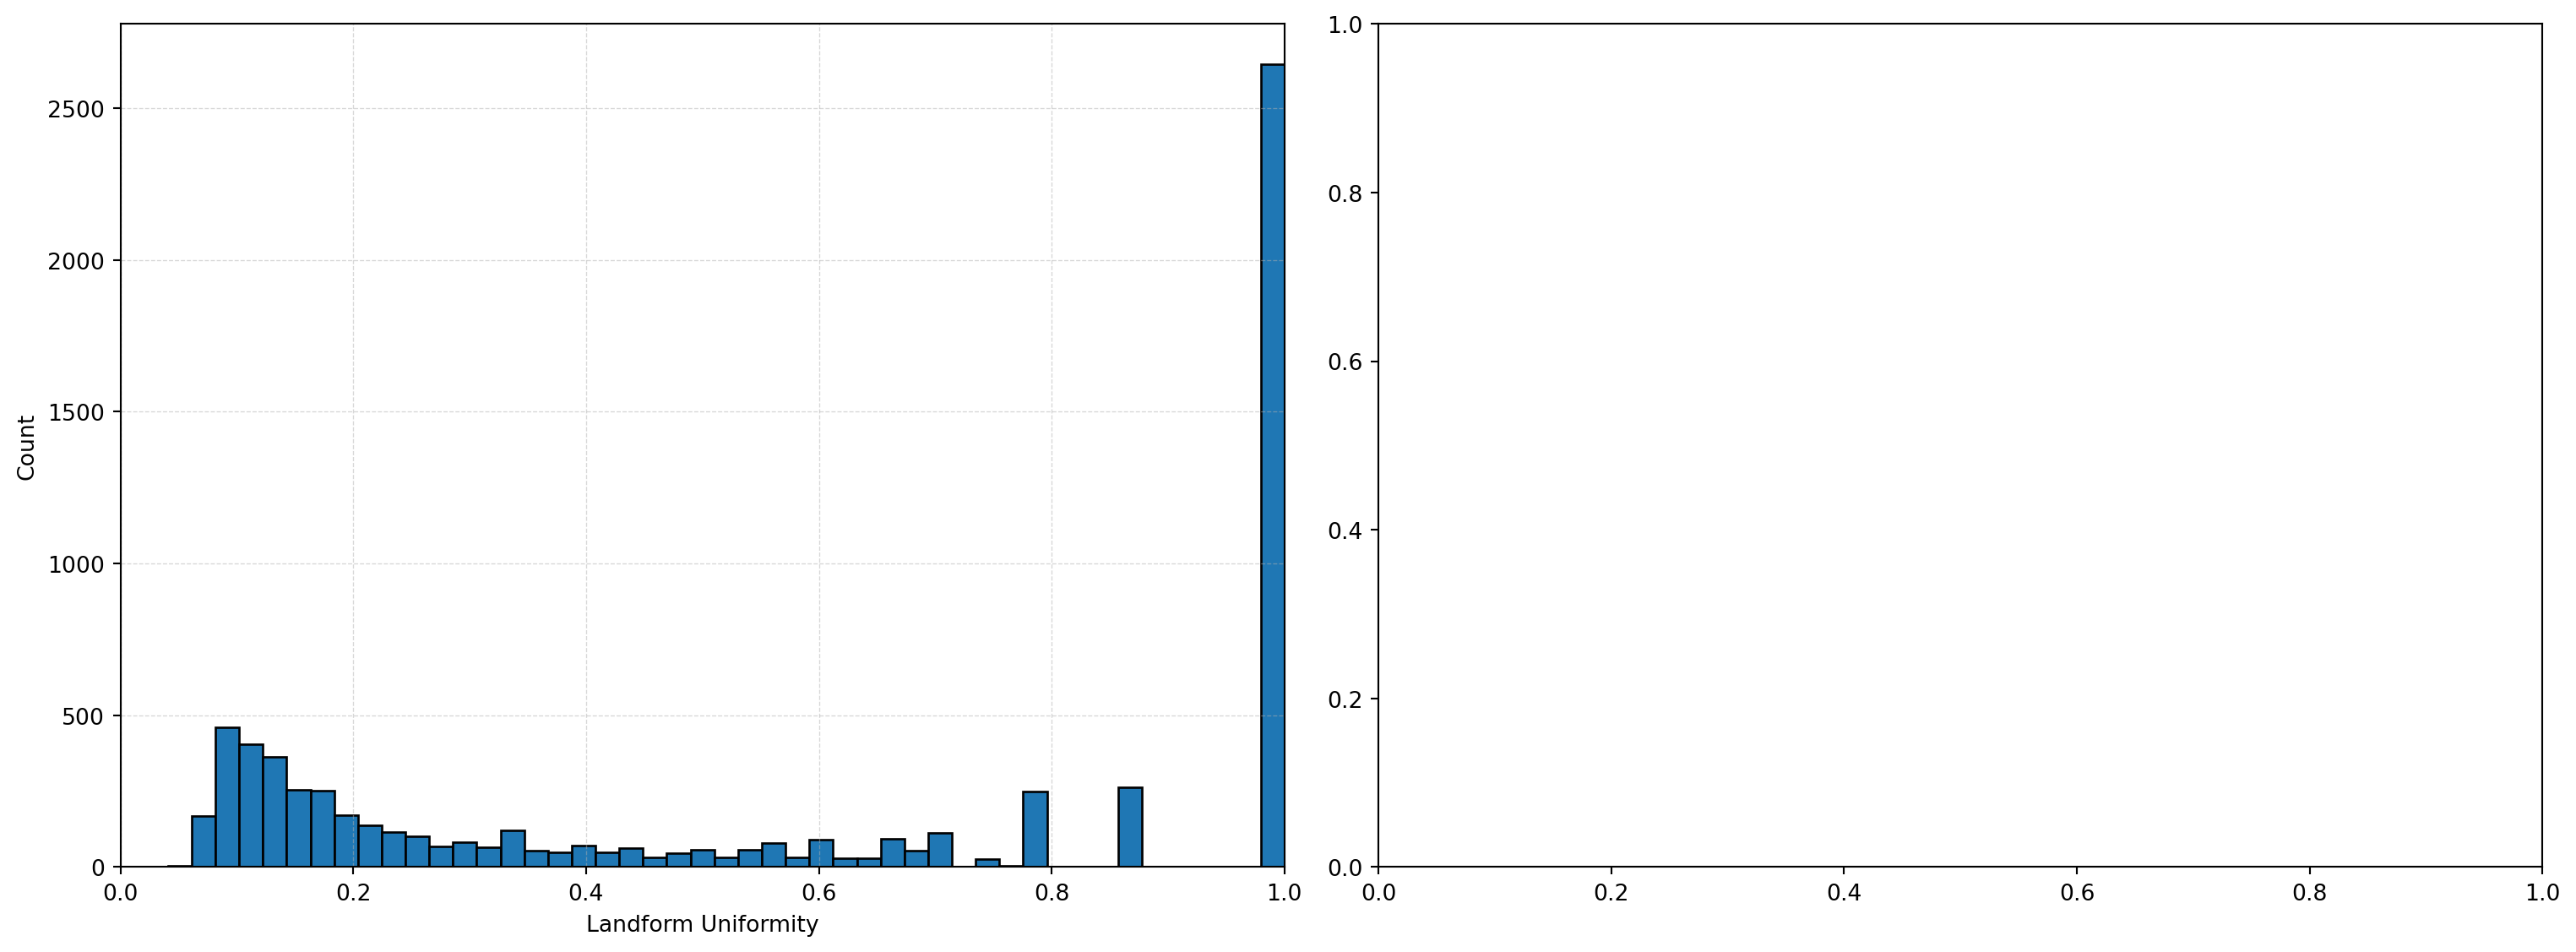

In [37]:
bins = np.linspace(0, 1, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df.loc[~m, var], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Landform Uniformity")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

# # bins = np.linspace(-0.0005, 0.0005, 50)
# bins = 50
# ax2.hist(np.log(us_df.loc[~m, var].values), bins=bins, edgecolor='black')
# ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
# ax2.set_xlabel("Ln(Landform Uniformity)")
# ax2.set_ylabel("Count")
# # ax2.set_xlim(bins.min(), bins.max())

fig.tight_layout()

Just min-max transform 

### Landform Shannon Index

In [38]:
var = vs30.constants.InputVariable.LandformShannonIndex
us_df[var].describe()

count    6989.000000
mean        0.622623
std         0.621108
min        -0.000000
25%         0.000000
50%         0.463414
75%         1.228106
max         2.046739
Name: landform_shannon_index, dtype: float64

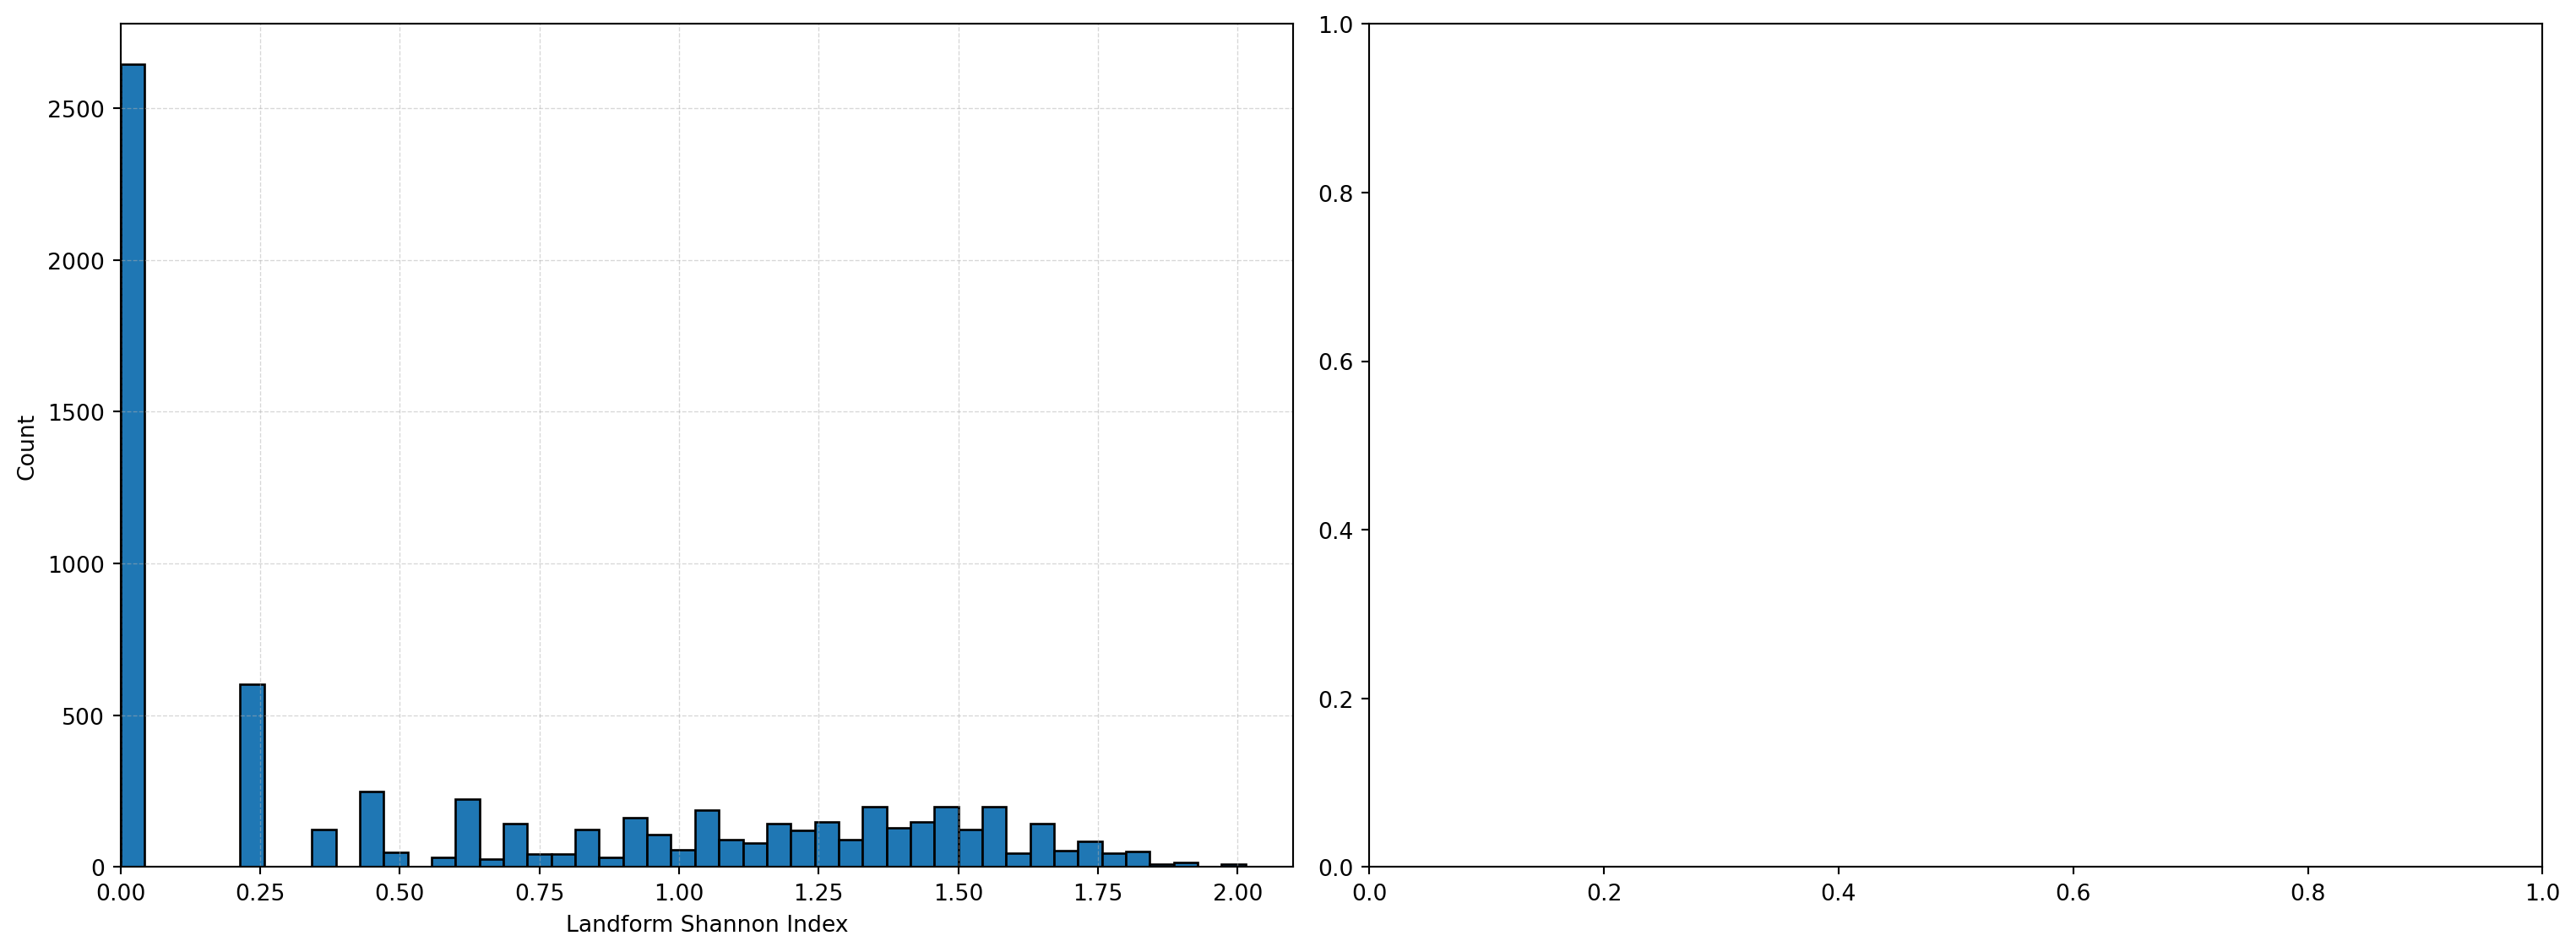

In [39]:
bins = np.linspace(0, 2.1, 50)
# bins=50

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 6))

ax1.hist(us_df.loc[~m, var], bins=bins, edgecolor='black')
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Landform Shannon Index")
ax1.set_ylabel("Count")
ax1.set_xlim(bins.min(), bins.max())

# # bins = np.linspace(-0.0005, 0.0005, 50)
# bins = 50
# ax2.hist(np.log(us_df.loc[~m, var].values), bins=bins, edgecolor='black')
# ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
# ax2.set_xlabel("Ln(Roughness)")
# ax2.set_ylabel("Count")
# # ax2.set_xlim(bins.min(), bins.max())

fig.tight_layout()

Min-max scaling again I guess. Need to determine sensible max value.